In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl
import pickle 
import time
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
import sklearn.metrics as sm
sns.set(style="whitegrid")
import matplotlib.gridspec as gridspec

from sklearn.model_selection import StratifiedKFold as skf
import seaborn as sns
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold as skf, GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.base import clone 
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance


### Análise Exploratória dos Dados (EDA) e pré-processamento

In [3]:
file_path_PK = "UDS.csv"

df_PK = pd.read_csv(file_path_PK, low_memory=False)

print("Dataset carregado com sucesso!")
print(f"Formato: {df_PK.shape}")
print(f"Colunas: {list(df_PK.columns)[:10]} ...")

Dataset carregado com sucesso!
Formato: (205908, 1024)
Colunas: ['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST'] ...


In [5]:
parkinson_cols_PK = ['PD', 'NACCPDMD']   
valid_cols_PK = [col for col in parkinson_cols_PK if col in df_PK.columns]

if not valid_cols_PK:
    print(" Nenhuma coluna de Parkinson encontrada no dataframe!")
else:
    print(f" Colunas utilizadas para identificar Parkinson: {valid_cols_PK}")

    parkinson_mask_PK = np.zeros(len(df_PK), dtype=bool)
    for col in valid_cols_PK:
        parkinson_mask_PK |= (df_PK[col] == 1)

    n_pacientes_parkinson_PK = df_PK.loc[parkinson_mask_PK, 'NACCID'].nunique()

    print(f"\nTotal de pacientes COM Parkinson no dataset: {n_pacientes_parkinson_PK:,}")

 Colunas utilizadas para identificar Parkinson: ['PD', 'NACCPDMD']

Total de pacientes COM Parkinson no dataset: 4,397


In [6]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 2000)      

print("Dimensões do dataset:", df_PK.shape)
print("\nPrimeiras linhas:")
display(df_PK.head(5))

print("\nLista de colunas do dataset:")
for col_PK in df_PK.columns:
    print(col_PK)

chaves_PK = [c_PK for c_PK in df_PK.columns if c_PK in [
    'NACCID','VISITMO','VISITYR','NACCVNUM','DEMENTED','NORMCOG','COGSTAT','NACCIDEM','MMSE','TRAILB','CDRSUM'
]]
print("\nColunas cognitivas e de diagnóstico encontradas:")
print(chaves_PK)

Dimensões do dataset: (205908, 1024)

Primeiras linhas:


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,NACCDAYS,NACCFDYS,NACCCORE,NACCREAS,NACCREFR,BIRTHMO,BIRTHYR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,RACETERX,PRIMLANG,PRIMLANX,EDUC,MARISTAT,NACCLIVS,INDEPEND,RESIDENC,HANDED,INBIRMO,INBIRYR,INSEX,NEWINF,INHISP,INHISPOR,INHISPOX,NACCNINR,INRACE,INRACEX,INRASEC,INRASECX,INRATER,INRATERX,INEDUC,INRELTO,INRELTOX,INKNOWN,INLIVWTH,INVISITS,INCALLS,INRELY,NACCFAM,NACCMOM,NACCDAD,NACCAM,NACCAMX,NACCAMS,NACCAMSX,NACCFM,NACCFMX,NACCFMS,NACCFMSX,NACCOM,NACCOMX,NACCOMS,NACCOMSX,NACCFADM,NACCFFTD,ANYMEDS,DRUG1,DRUG2,DRUG3,DRUG4,DRUG5,DRUG6,DRUG7,DRUG8,DRUG9,DRUG10,DRUG11,DRUG12,DRUG13,DRUG14,DRUG15,DRUG16,DRUG17,DRUG18,DRUG19,DRUG20,DRUG21,DRUG22,DRUG23,DRUG24,DRUG25,DRUG26,DRUG27,DRUG28,DRUG29,DRUG30,DRUG31,DRUG32,DRUG33,DRUG34,DRUG35,DRUG36,DRUG37,DRUG38,DRUG39,DRUG40,TOBAC30,TOBAC100,SMOKYRS,PACKSPER,QUITSMOK,ALCOCCAS,ALCFREQ,CVHATT,HATTMULT,HATTYEAR,CVAFIB,CVANGIO,CVBYPASS,CVPACDEF,CVPACE,CVCHF,CVANGINA,CVHVALVE,CVOTHR,CVOTHRX,CBSTROKE,STROKMUL,NACCSTYR,CBTIA,TIAMULT,NACCTIYR,PD,PDYR,PDOTHR,PDOTHRYR,SEIZURES,NACCTBI,TBI,TBIBRIEF,TRAUMBRF,TBIEXTEN,TRAUMEXT,TBIWOLOS,TRAUMCHR,TBIYEAR,NCOTHR,NCOTHRX,DIABETES,DIABTYPE,HYPERTEN,HYPERCHO,B12DEF,THYROID,ARTHRIT,ARTHTYPE,ARTHTYPX,ARTHUPEX,ARTHLOEX,ARTHSPIN,ARTHUNK,INCONTU,INCONTF,APNEA,RBD,INSOMN,OTHSLEEP,OTHSLEEX,ALCOHOL,ABUSOTHR,ABUSX,PTSD,BIPOLAR,SCHIZ,DEP2YRS,DEPOTHR,ANXIETY,OCD,NPSYDEV,PSYCDIS,PSYCDISX,HEIGHT,WEIGHT,BPSYS,BPDIAS,HRATE,VISION,VISCORR,VISWCORR,HEARING,HEARAID,HEARWAID,ABRUPT,STEPWISE,SOMATIC,EMOT,HXHYPER,HXSTROKE,FOCLSYM,FOCLSIGN,HACHIN,CVDCOG,STROKCOG,CVDIMAG,CVDIMAG1,CVDIMAG2,CVDIMAG3,CVDIMAG4,CVDIMAGX,PDNORMAL,SPEECH,SPEECHX,FACEXP,FACEXPX,TRESTFAC,TRESTFAX,TRESTRHD,TRESTRHX,TRESTLHD,TRESTLHX,TRESTRFT,TRESTRFX,TRESTLFT,TRESTLFX,TRACTRHD,TRACTRHX,TRACTLHD,TRACTLHX,RIGDNECK,RIGDNEX,RIGDUPRT,RIGDUPRX,RIGDUPLF,RIGDUPLX,RIGDLORT,RIGDLORX,RIGDLOLF,RIGDLOLX,TAPSRT,TAPSRTX,TAPSLF,TAPSLFX,HANDMOVR,HANDMVRX,HANDMOVL,HANDMVLX,HANDALTR,HANDATRX,HANDALTL,HANDATLX,LEGRT,LEGRTX,LEGLF,LEGLFX,ARISING,ARISINGX,POSTURE,POSTUREX,GAIT,GAITX,POSSTAB,POSSTABX,BRADYKIN,BRADYKIX,MEMORY,ORIENT,JUDGMENT,COMMUN,HOMEHOBB,PERSCARE,CDRSUM,CDRGLOB,COMPORT,CDRLANG,NPIQINF,NPIQINFX,DEL,DELSEV,HALL,HALLSEV,AGIT,AGITSEV,DEPD,DEPDSEV,ANX,ANXSEV,ELAT,ELATSEV,APA,APASEV,DISN,DISNSEV,IRR,IRRSEV,MOT,MOTSEV,NITE,NITESEV,APP,APPSEV,NOGDS,SATIS,DROPACT,EMPTY,BORED,SPIRITS,AFRAID,HAPPY,HELPLESS,STAYHOME,MEMPROB,WONDRFUL,WRTHLESS,ENERGY,HOPELESS,BETTER,NACCGDS,BILLS,TAXES,SHOPPING,GAMES,STOVE,MEALPREP,EVENTS,PAYATTN,REMDATES,TRAVEL,NACCNREX,NORMEXAM,FOCLDEF,GAITDIS,EYEMOVE,PARKSIGN,RESTTRL,RESTTRR,SLOWINGL,SLOWINGR,RIGIDL,RIGIDR,BRADY,PARKGAIT,POSTINST,CVDSIGNS,CORTDEF,SIVDFIND,CVDMOTL,CVDMOTR,CORTVISL,CORTVISR,SOMATL,SOMATR,POSTCORT,PSPCBS,EYEPSP,DYSPSP,AXIALPSP,GAITPSP,APRAXSP,APRAXL,APRAXR,CORTSENL,CORTSENR,ATAXL,ATAXR,ALIENLML,ALIENLMR,DYSTONL,DYSTONR,MYOCLLT,MYOCLRT,ALSFIND,GAITNPH,OTHNEUR,OTHNEURX,B9CHG,DECSUB,DECIN,DECCLIN,DECCLCOG,COGMEM,COGORI,COGJUDG,COGLANG,COGVIS,COGATTN,COGFLUC,COGFLAGO,COGOTHR,COGOTHRX,NACCCOGF,NACCCGFX,COGMODE,COGMODEX,DECAGE,DECCLBE,BEAPATHY,BEDEP,BEVHALL,BEVWELL,BEVHAGO,BEAHALL,BEDEL,BEDISIN,BEIRRIT,BEAGIT,BEPERCH,BEREM,BEREMAGO,BEANX,BEOTHR,BEOTHRX,NACCBEHF,NACCBEFX,BEMODE,BEMODEX,BEAGE,DECCLMOT,MOGAIT,MOFALLS,MOTREM,MOSLOW,NACCMOTF,MOMODE,MOMODEX,MOMOPARK,PARKAGE,MOMOALS,ALSAGE,MOAGE,COURSE,FRSTCHG,LBDEVAL,FTLDEVAL,MMSECOMP,MMSELOC,MMSELAN,MMSELANX,MMSEVIS,MMSEHEAR,MMSEORDA,MMSEORLO,PENTAGON,NACCMMSE,NPSYCLOC,NPSYLAN,NPSYLANX,LOGIMO,LOGIDAY,LOGIYR,LOGIPREV,LOGIMEM,MEMUNITS,MEMTIME,UDSBENTC,UDSBENTD,UDSBENRS,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,TRAILB,TRAILBRR,TRAILBLI,WAIS,BOSTON,UDSVERFC,UDSVERFN,UDSVERNF,UDSVERLC,UDSVERLR,UDSVERLN,UDSVERTN,UDSVERTE,UDSVERTI,COGSTAT,NACCC1,MOCACOMP,MOCAREAS,MOCALOC,MOCALAN,MOCALANX,MOCAVIS,MOCAHEAR,MOCATOTS,MOCATRAI,MOCACUBE,MOCACLOC,MOCACLON,MOCACLOH,MOCANAMI,MOCAREGI,MOCADIGI,MOCALETT,MOCASER7,MOCAREPE,MOCAFL


Lista de colunas do dataset:
NACCID
NACCADC
PACKET
FORMVER
VISITMO
VISITDAY
VISITYR
NACCVNUM
NACCAVST
NACCNVST
NACCDAYS
NACCFDYS
NACCCORE
NACCREAS
NACCREFR
BIRTHMO
BIRTHYR
SEX
HISPANIC
HISPOR
HISPORX
RACE
RACEX
RACESEC
RACESECX
RACETER
RACETERX
PRIMLANG
PRIMLANX
EDUC
MARISTAT
NACCLIVS
INDEPEND
RESIDENC
HANDED
INBIRMO
INBIRYR
INSEX
NEWINF
INHISP
INHISPOR
INHISPOX
NACCNINR
INRACE
INRACEX
INRASEC
INRASECX
INRATER
INRATERX
INEDUC
INRELTO
INRELTOX
INKNOWN
INLIVWTH
INVISITS
INCALLS
INRELY
NACCFAM
NACCMOM
NACCDAD
NACCAM
NACCAMX
NACCAMS
NACCAMSX
NACCFM
NACCFMX
NACCFMS
NACCFMSX
NACCOM
NACCOMX
NACCOMS
NACCOMSX
NACCFADM
NACCFFTD
ANYMEDS
DRUG1
DRUG2
DRUG3
DRUG4
DRUG5
DRUG6
DRUG7
DRUG8
DRUG9
DRUG10
DRUG11
DRUG12
DRUG13
DRUG14
DRUG15
DRUG16
DRUG17
DRUG18
DRUG19
DRUG20
DRUG21
DRUG22
DRUG23
DRUG24
DRUG25
DRUG26
DRUG27
DRUG28
DRUG29
DRUG30
DRUG31
DRUG32
DRUG33
DRUG34
DRUG35
DRUG36
DRUG37
DRUG38
DRUG39
DRUG40
TOBAC30
TOBAC100
SMOKYRS
PACKSPER
QUITSMOK
ALCOCCAS
ALCFREQ
CVHATT
HATTMULT
HATTYEAR
CVAFIB
CV

In [7]:
df_PK['visit_date_PK'] = pd.to_datetime(
    dict(year=df_PK['VISITYR'], month=df_PK['VISITMO'], day=df_PK['VISITDAY']),
    errors='coerce'
)

ano_min_PK = int(df_PK['VISITYR'].min())
ano_max_PK = int(df_PK['VISITYR'].max())
print(f"O dataset cobre o período de {ano_min_PK} até {ano_max_PK}.")

print("\nDistribuição de registros por ano:")
print(df_PK['VISITYR'].value_counts().sort_index())

baseline_por_ano_PK = (
    df_PK.sort_values(['NACCID','VISITYR','VISITMO'])
             .groupby('NACCID', as_index=False)
             .first()['VISITYR']
             .value_counts()
             .sort_index()
)
print("\nParticipantes cuja primeira visita foi em cada ano:")
print(baseline_por_ano_PK)

O dataset cobre o período de 2005 até 2025.

Distribuição de registros por ano:
VISITYR
2005     1971
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015    10005
2016     9900
2017    10139
2018    10616
2019    11003
2020     8362
2021     8877
2022    10396
2023    11662
2024    11046
2025     2051
Name: count, dtype: int64

Participantes cuja primeira visita foi em cada ano:
VISITYR
2005    1971
2006    8458
2007    4918
2008    3397
2009    2776
2010    2475
2011    2185
2012    2425
2013    2090
2014    1812
2015    1660
2016    1914
2017    2505
2018    2479
2019    2460
2020     956
2021    1582
2022    2712
2023    3252
2024    2626
2025     351
Name: count, dtype: int64


In [8]:
df_PK['visit_date_PK'] = pd.to_datetime(
    dict(year=df_PK['VISITYR'], month=df_PK['VISITMO'], day=df_PK['VISITDAY']),
    errors='coerce'
)

inicio_PK = pd.Timestamp('2005-09-01')
fim_PK = pd.Timestamp('2015-02-28')

df_periodo_PK = df_PK[(df_PK['visit_date_PK'] >= inicio_PK) & (df_PK['visit_date_PK'] <= fim_PK)].copy()

print(f"linhas após filtro: {df_periodo_PK.shape[0]:,}")
print(f"Participantes únicos: {df_periodo_PK['NACCID'].nunique():,}")
print(f"Intervalo de datas: {df_periodo_PK['visit_date_PK'].min().date()} → {df_periodo_PK['visit_date_PK'].max().date()}")

print("\nDistribuição de visitas por ano:")
print(df_periodo_PK['VISITYR'].value_counts().sort_index())

linhas após filtro: 103,423
Participantes únicos: 32,828
Intervalo de datas: 2005-09-01 → 2015-02-27

Distribuição de visitas por ano:
VISITYR
2005     1958
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015     1585
Name: count, dtype: int64


In [9]:
df_clean_PK = df_periodo_PK.copy()

missing_codes_PK = [8, 88, 888, 8888, 9, 99, 999, 9999, -4, -88, -99]

df_clean_PK = df_clean_PK.replace(missing_codes_PK, np.nan)


if 'PACKET' in df_clean_PK.columns:
    before_PK = df_clean_PK.shape[0]
    df_clean_PK = df_clean_PK[df_clean_PK['PACKET'].astype(str).str.upper() != 'T']
    print(f"Visitas telefônicas removidas: {before_PK - df_clean_PK.shape[0]}")

df_clean_PK['visit_date_PK'] = pd.to_datetime(
    dict(year=df_clean_PK['VISITYR'], month=df_clean_PK['VISITMO'], day=df_clean_PK.get('VISITDAY', 1)),
    errors='coerce'
)

before_PK = df_clean_PK.shape[0]
df_clean_PK = df_clean_PK[df_clean_PK['visit_date_PK'].notna()]
print(f"Registros sem data removidos: {before_PK - df_clean_PK.shape[0]}")

baseline_dates_PK = (
    df_clean_PK[df_clean_PK['NACCVNUM'] == 1][['NACCID', 'visit_date_PK']]
    .rename(columns={'visit_date_PK': 'baseline_date_PK'})
)
df_clean_PK = df_clean_PK.merge(baseline_dates_PK, on='NACCID', how='left')
df_clean_PK['months_from_baseline_PK'] = (
    (df_clean_PK['visit_date_PK'] - df_clean_PK['baseline_date_PK']).dt.days / 30.44
)

print("\nResumo após limpeza:")
print(f"Linhas finais: {df_clean_PK.shape[0]:,}")
print(f"Participantes únicos: {df_clean_PK['NACCID'].nunique():,}")
print(f"Período: {df_clean_PK['visit_date_PK'].min().date()} → {df_clean_PK['visit_date_PK'].max().date()}")
print(f"Faixa de meses desde baseline: {df_clean_PK['months_from_baseline_PK'].min():.1f} → {df_clean_PK['months_from_baseline_PK'].max():.1f}")

Visitas telefônicas removidas: 5191
Registros sem data removidos: 22314

Resumo após limpeza:
Linhas finais: 75,918
Participantes únicos: 29,389
Período: 2005-10-01 → 2015-02-27
Faixa de meses desde baseline: 0.0 → 112.7


In [10]:
tabela_nacc_PK = (
        df_PK["DEMENTED"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência_PK")
    )
tabela_nacc_PK["%_PK"] = (tabela_nacc_PK["Frequência_PK"] / tabela_nacc_PK["Frequência_PK"].sum() * 100).round(2)

print("\nDistribuição da variável DEMENTED:")
display(tabela_nacc_PK)


Distribuição da variável DEMENTED:


,Código Diagnóstico,Frequência_PK,%_PK
0,0,146336,71.07
1,1,59572,28.93


In [11]:
tabela_nacc_PK = (
        df_PK["NACCUDSD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência_PK")
    )
tabela_nacc_PK["%_PK"] = (tabela_nacc_PK["Frequência_PK"] / tabela_nacc_PK["Frequência_PK"].sum() * 100).round(2)

print("\nDistribuição da variável NACCUDSD:")
display(tabela_nacc_PK)


Distribuição da variável NACCUDSD:


,Código Diagnóstico,Frequência_PK,%_PK
0,1,100992,49.05
1,2,9090,4.41
2,3,36254,17.61
3,4,59572,28.93


In [12]:
tabela_nacc_PK = (
        df_PK["PD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência_PK")
    )
tabela_nacc_PK["%_PK"] = (tabela_nacc_PK["Frequência_PK"] / tabela_nacc_PK["Frequência_PK"].sum() * 100).round(2)

print("\nDistribuição da variável PD:")
display(tabela_nacc_PK)


Distribuição da variável PD:


,Código Diagnóstico,Frequência_PK,%_PK
0,-4,79893,38.8
1,0,122921,59.7
2,1,2685,1.3
3,9,409,0.2


 Pacientes com Parkinson (em qualquer visita): 2,121
 Pacientes COM Parkinson na baseline: 1,063

======== RESUMO FINAL =========
Total de participantes COM Parkinson na baseline: 1,063
 Demência incidente: 160 (15.05%)

 Range de meses até follow-up (apenas incidentes):
count    12220.000000
mean        30.497797
std         19.084107
min          1.675427
25%         13.337714
50%         24.934297
75%         40.243101
max        109.526938
Name: months_from_baseline_PK, dtype: float64


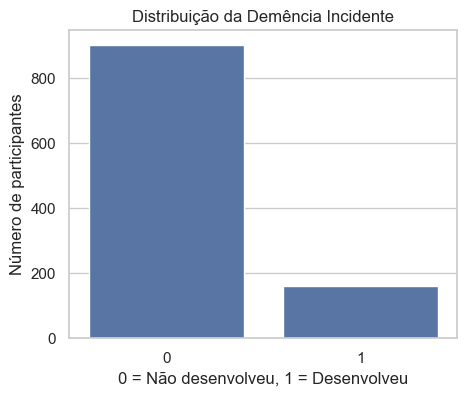


 Dataset final pronto para modelagem!
 1063 pacientes × 1028 variáveis


In [13]:



df_clean_PK['months_from_baseline_PK'] = pd.to_numeric(
    df_clean_PK['months_from_baseline_PK'],
    errors='coerce'
)


parkinson_cols = ['PD', 'NACCPDMD']
parkinson_cols = [c for c in parkinson_cols if c in df_clean_PK.columns]

if not parkinson_cols:
    raise ValueError("Nenhuma coluna de Parkinson encontrada (PD / NACCPDMD).")

parkinson_ids = df_clean_PK.loc[
    df_clean_PK[parkinson_cols].eq(1).any(axis=1),
    'NACCID'
].unique()

print(f" Pacientes com Parkinson (em qualquer visita): {len(parkinson_ids):,}")



baseline = df_clean_PK[
    (df_clean_PK['NACCVNUM'] == 1) &  
    (df_clean_PK['NACCID'].isin(parkinson_ids)) &  
    (df_clean_PK['DEMENTED'] == 0) &  
    (df_clean_PK['FORMVER'] < 3) &    
    (df_clean_PK['PACKET'].astype(str).str.upper() != 'T')  
].copy()

print(f" Pacientes COM Parkinson na baseline: {baseline['NACCID'].nunique():,}")


followup = df_clean_PK[
    (df_clean_PK['NACCVNUM'] > 1) &        
    (df_clean_PK['DEMENTED'] == 1)         
][['NACCID', 'months_from_baseline_PK']]

incident_ids = followup['NACCID'].unique()



df_final_PK = baseline.copy()
df_final_PK['incident_dementia_PK'] = df_final_PK['NACCID'].isin(incident_ids).astype(int)

total_participants = df_final_PK['NACCID'].nunique()
n_dementia = df_final_PK['incident_dementia_PK'].sum()
perc_dementia = (n_dementia / total_participants) * 100

print("\n======== RESUMO FINAL =========")
print(f"Total de participantes COM Parkinson na baseline: {total_participants:,}")
print(f" Demência incidente: {n_dementia:,} ({perc_dementia:.2f}%)")



followup_incident = followup[followup['NACCID'].isin(incident_ids)]

print("\n Range de meses até follow-up (apenas incidentes):")
print(followup_incident['months_from_baseline_PK'].describe())


plt.figure(figsize=(5,4))
sns.countplot(x=df_final_PK['incident_dementia_PK'])
plt.title("Distribuição da Demência Incidente")
plt.xlabel("0 = Não desenvolveu, 1 = Desenvolveu")
plt.ylabel("Número de participantes")
plt.show()


print("\n Dataset final pronto para modelagem!")
print(f" {df_final_PK.shape[0]} pacientes × {df_final_PK.shape[1]} variáveis")


In [14]:

parkinson_cols_PK = ['PD', 'NACCPDMD']
valid_cols_PK = [col for col in parkinson_cols_PK if col in df_PK.columns]

if not valid_cols_PK:
    print("Nenhuma coluna de Parkinson encontrada no dataframe!")
else:
    print(f" Colunas utilizadas para identificar Parkinson: {valid_cols_PK}")

    parkinson_mask_PK = np.zeros(len(df_PK), dtype=bool)
    for col in valid_cols_PK:
        parkinson_mask_PK |= (df_PK[col] == 1)

    n_pacientes_parkinson_PK = df_PK.loc[parkinson_mask_PK, 'NACCID'].nunique()

    print(f"\nTotal de pacientes COM Parkinson no dataset: {n_pacientes_parkinson_PK:,}")

 Colunas utilizadas para identificar Parkinson: ['PD', 'NACCPDMD']

Total de pacientes COM Parkinson no dataset: 4,397


In [15]:
base_PK = df_final_PK[['NACCID','VISITYR','incident_dementia_PK']].drop_duplicates('NACCID')
tab_PK = (base_PK
             .groupby('VISITYR', as_index=False)
             .agg(n_baseline_PK=('NACCID','nunique'),
                  n_incident_PK=('incident_dementia_PK','sum')))
tab_PK['perc_incident_%_PK'] = 100*tab_PK['n_incident_PK']/tab_PK['n_baseline_PK']
tab_PK.sort_values('VISITYR', inplace=True)
tab_PK

,VISITYR,n_baseline_PK,n_incident_PK,perc_incident_%_PK
0,2005,69,13,18.840580
1,2006,284,49,17.253521
2,2007,186,33,17.741935
3,2008,113,14,12.389381
4,2009,94,20,21.276596
5,2010,86,12,13.953488
6,2011,57,6,10.526316
7,2012,60,8,13.333333
8,2013,53,4,7.547170
9,2014,50,1,2.000000


<Axes: >

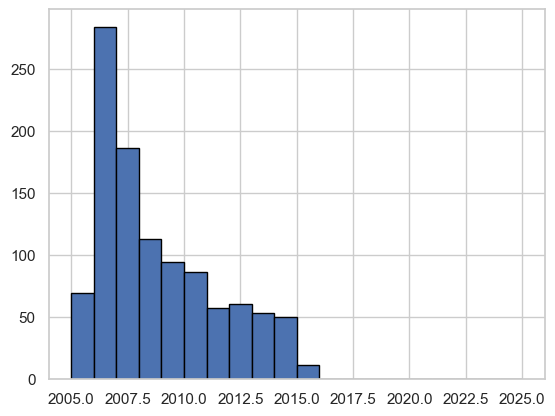

In [16]:
df_final_PK['VISITYR'].hist(bins=range(2005, 2026), edgecolor='black')


In [17]:
df_no_PK = df_final_PK[df_final_PK["incident_dementia_PK"] == 0]
df_inc_PK = df_final_PK[df_final_PK["incident_dementia_PK"] == 1]

n_no_PK = df_no_PK.shape[0]
n_inc_PK = df_inc_PK.shape[0]

print("\n========== PARTICIPANT COUNTS ==========")
print(f"No incident dementia:  {n_no_PK}")
print(f"Incident dementia:     {n_inc_PK}")


def mean_sd_raw(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return s.mean(), s.std()

def count_pct_raw(series, value):
    s = series.dropna()
    c = np.sum(s == value)
    return c, (c/len(s))*100

def median_iqr_raw(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return (
        np.median(s),
        np.percentile(s,25),
        np.percentile(s,75)
    )


print("\n========== AGE ==========")
print("No dementia:", mean_sd_raw(df_no_PK["NACCAGE"]))
print("Incident dementia:", mean_sd_raw(df_inc_PK["NACCAGE"]))

print("\n========== SEX ==========")
print("Men (no dementia):", count_pct_raw(df_no_PK["SEX"], 1))
print("Women (no dementia):", count_pct_raw(df_no_PK["SEX"], 2))
print("Men (incident dementia):", count_pct_raw(df_inc_PK["SEX"], 1))
print("Women (incident dementia):", count_pct_raw(df_inc_PK["SEX"], 2))

print("\n========== LANGUAGE (PRIMLANG) ==========")
print("English speaker (no dementia):", count_pct_raw(df_no_PK["PRIMLANG"], 1))
print("English speaker (incident dementia):", count_pct_raw(df_inc_PK["PRIMLANG"], 1))

print("\n========== EDUCATION ==========")
print("No dementia:", mean_sd_raw(df_no_PK["EDUC"]))
print("Incident dementia:", mean_sd_raw(df_inc_PK["EDUC"]))

print("\n========== DEPENDENT LIVING (INDEPEND=2) ==========")
print("No dementia:", count_pct_raw(df_no_PK["INDEPEND"], 2))
print("Incident dementia:", count_pct_raw(df_inc_PK["INDEPEND"], 2))

print("\n========== CDR SUM ==========")
print("No dementia:", median_iqr_raw(df_no_PK["CDRSUM"]))
print("Incident dementia:", median_iqr_raw(df_inc_PK["CDRSUM"]))

print("\n========== MMSE ==========")
print("No dementia:", mean_sd_raw(df_no_PK["NACCMMSE"]))
print("Incident dementia:", mean_sd_raw(df_inc_PK["NACCMMSE"]))


def mean_sd(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{s.mean():.1f} ({s.std():.1f})"

def count_pct(series, value):
    s = series.dropna()
    c = np.sum(s == value)
    return f"{c} ({(c/len(s))*100:.0f})"

def median_iqr(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{np.median(s):.1f} ({np.percentile(s,25):.1f}-{np.percentile(s,75):.1f})"

table1 = {
    "Characteristic": [
        "Age, mean (SD)",
        "Sex: Men",
        "Sex: Women",
        "Native English speaker",
        "Education, mean (SD), years",
        "Dependent living",
        "CDR sum, median (IQR)",
        "Total MMSE score, mean (SD)"
    ],

    "No incident dementia": [
        mean_sd(df_no_PK["NACCAGE"]),
        count_pct(df_no_PK["SEX"], 1),
        count_pct(df_no_PK["SEX"], 2),
        count_pct(df_no_PK["PRIMLANG"], 1),
        mean_sd(df_no_PK["EDUC"]),
        count_pct(df_no_PK["INDEPEND"], 2),
        median_iqr(df_no_PK["CDRSUM"]),
        mean_sd(df_no_PK["NACCMMSE"])
    ],

    "Incident dementia": [
        mean_sd(df_inc_PK["NACCAGE"]),
        count_pct(df_inc_PK["SEX"], 1),
        count_pct(df_inc_PK["SEX"], 2),
        count_pct(df_inc_PK["PRIMLANG"], 1),
        mean_sd(df_inc_PK["EDUC"]),
        count_pct(df_inc_PK["INDEPEND"], 2),
        median_iqr(df_inc_PK["CDRSUM"]),
        mean_sd(df_inc_PK["NACCMMSE"])
    ]
}

df_table1 = pd.DataFrame(table1)

print("\n============================")
print(" Tabela 1 — Sample Characteristics")
print("============================\n")
display(df_table1)

df_table1.to_csv("5fold_PK/Table1_Sample_Characteristics_PK.csv", index=False)
print("\nArquivo salvo em: 5fold_PK/Table1_Sample_Characteristics.csv")



========== PARTICIPANT COUNTS ==========
No incident dementia:  903
Incident dementia:     160

========== AGE ==========
No dementia: (np.float64(70.42569832402235), np.float64(9.295473444273028))
Incident dementia: (np.float64(74.22151898734177), np.float64(8.996548112068217))

========== SEX ==========
Men (no dementia): (np.int64(451), np.float64(49.944629014396455))
Women (no dementia): (np.int64(452), np.float64(50.055370985603545))
Men (incident dementia): (np.int64(107), np.float64(66.875))
Women (incident dementia): (np.int64(53), np.float64(33.125))

========== LANGUAGE (PRIMLANG) ==========
English speaker (no dementia): (np.int64(868), np.float64(96.875))
English speaker (incident dementia): (np.int64(149), np.float64(95.51282051282051))

========== EDUCATION ==========
No dementia: (np.float64(15.835400225479143), np.float64(2.9973593406262915))
Incident dementia: (np.float64(15.539473684210526), np.float64(3.2569468881784784))

========== DEPENDENT LIVING (INDEPEND=2) ==

,Characteristic,No incident dementia,Incident dementia
0,"Age, mean (SD)",70.4 (9.3),74.2 (9.0)
1,Sex: Men,451 (50),107 (67)
2,Sex: Women,452 (50),53 (33)
3,Native English speaker,868 (97),149 (96)
4,"Education, mean (SD), years",15.8 (3.0),15.5 (3.3)
5,Dependent living,125 (14),60 (38)
6,"CDR sum, median (IQR)",0.0 (0.0-1.0),1.5 (0.5-2.5)
7,"Total MMSE score, mean (SD)",29.6 (8.8),28.4 (9.9)



Arquivo salvo em: 5fold_PK/Table1_Sample_Characteristics.csv


In [59]:
predictor_vars_PK = [
    # --- Demográficos / Identificação ---
    "NACCREAS","NACCREFR","BIRTH_#MOS","SEX","HISPANIC","HISPOR","PRIMLANG","EDUC","NACCLIVS","INDEPEND","RESIDENC","MARISTAT","HANDED","NACCAGE","NACCNIHR",
    "INBIR_#MOS","INSEX","INRELTO","INLIVWTH","INVISITS","INCALLS","INRELY","NACCMOM","NACCDAD","NACCFAM","ANYMEDS",
    # --- Medicamentos / Condições médicas ---
    "NACCAMD","NACCHTNC","NACCACEI","NACCAAAS","NACCBETA","NACCCCBS","NACCDIUR","NACCVASD","NACCANGI","NACCAHTN",
    "NACCLIPL","NACCNSD","NACCAC","NACCADEP","NACCAPSY","NACCAANX","NACCEMD","NACCEPMD","NACCDBMD",
    # --- Exames clínicos e vitais ---
    "BPSYS","BPDIAS","HRATE","VISION","VISCORR","VISWCORR","HEARING","HEARAID","HEARWAID","NACCBMI","ABRUPT","STEPWISE","SOMATIC","EMOT",
    # --- Doenças cardiovasculares e neurológicas ---
    "CVHATT","CVAFIB","CVANGIO","CVBYPASS","CVPACE","CVCHF","CVOTHR","CBSTROKE","NACCSTYR_#YRS","CBTIA","NACCTIYR_#YRS","PDYR_#YRS","PDOTHR","PDOTHRYR_#YRS","SEIZURES","TRAUMBRF","TRAUMEXT","TRAUMCHR","NCOTHR","HYPERTEN","HYPERCHO","DIABETES","B12DEF","THYROID",
    "INCONTU","INCONTF","DEP2YRS","DEPOTHR","ALCOHOL","TOBAC30","TOBAC100","SMOKYRS","PACKSPER","QUITSMOK","ABUSOTHR","PSYCDIS","NACCTBI",
    # --- Neurológico / Motricidade / Parkinsonismo ---
    "GAIT","POSSTAB","BRADYKIN","PDNORMAL","FOCLSYM","FOCLSIGN","HACHIN","HXHYPER","HXSTROKE","SPEECH","FACEXP",
    "TRESTFAC","TRESTLHD","TRESTLFT","TRESTFHD","TRESTRHD","TRESTRFT","RIGDNECK","RIGDUPRT","RIGDUPLF","RIGDLORT",
    "RIGDLOLF","TAPSRT","TAPSLF","HANDMOVR","HANDMOVL","HANDALTR","HANDALTL","LEGRT","LEGLF","ARISING","POSTURE",
    # --- Avaliação cognitiva / CDR ---
    "MEMORY","ORIENT","JUDGMENT","COMMUN","HOMEHOBB","PERSCARE","CDRSUM","CDRGLOB","COGSTAT","NACCC1",
    # --- Testes neuropsicológicos ---
    "MMSELOC","MMSELAN","MMSEORDA","MMSEORDA_PROB","MMSEORLO","MMSEORLO_PROB","NACCMMSE","NACCMMSE_PROB",
    "NPSYCLOC","NPSYLAN","LOGIMEM","LOGIMEM_PROB","DIGIF","DIGIF_PROB","DIGIFLEN","DIGIFLEN_PROB","DIGIB","DIGIB_PROB",
    "DIGIBLEN","DIGIBLEN_PROB","ANIMALS","ANIMALS_PROB","VEG","VEG_PROB","TRAILA","TRAILA_PROB","TRAILB","TRAILB_PROB",
    "WAIS","WAIS_PROB","MEMUNITS","MEMUNITS_PROB","MEMTIME","BOSTON","BOSTON_PROB",
    # --- Depressão e comportamento ---
    "NACCGDS","NACCBEHF","NACCBEFX","BEAPATHY","BEDEP","BEVHALL","BEAHALL","BEDEL","BEDISIN","BEIRRIT","BEAGIT","BEPERCH","BEOTHR",
    "SATIS","DROPACT","EMPTY","BORED","SPIRITS","AFRAID","HAPPY","HELPLESS","STAYHOME","MEMPROB","WONDRFUL","WRTHLESS","ENERGY","HOPELESS","BETTER",
    # --- Funcionalidade diária ---
    "BILLS","TAXES","SHOPPING","GAMES","STOVE","MEALPREP","EVENTS","PAYATTN","REMDATES","TRAVEL","FOCLDEF","GAITDIS","EYEMOVE",
    # --- Movimento e modo ---
    "MOGAIT","MOFALLS","MOTREM","MOSLOW","NACCMOTF","MOMODE","COURSE","FRSTCHG","DECIN","DECSUB","DECAGE","COGMEM","COGJUDG","COGLANG","COGVIS","COGATTN","COGOTHR","COGMODE",
    # --- Variáveis aleatórias auxiliares ---
    "RANDVAR_0","RANDVAR_1","RANDVAR_2","RANDVAR_3",
]



cols_present_PK = [col for col in predictor_vars_PK if col in df_final_PK.columns]
cols_missing_PK = [col for col in predictor_vars_PK if col not in df_final_PK.columns]

print(f"Total de variáveis esperadas: {len(predictor_vars_PK)}")
print(f"Encontradas no dataset: {len(cols_present_PK)}")
print(f"Ausentes: {len(cols_missing_PK)}")

print("\nExemplo de variáveis ausentes:")
print(cols_missing_PK[:30])

X_PK = df_final_PK[cols_present_PK].copy()
y_PK = df_final_PK['incident_dementia_PK']

print(f"\nShape de X_PK: {X_PK.shape}")
print(f"Shape de y_PK: {y_PK.shape}")

Total de variáveis esperadas: 236
Encontradas no dataset: 210
Ausentes: 26

Exemplo de variáveis ausentes:
['BIRTH_#MOS', 'INBIR_#MOS', 'NACCSTYR_#YRS', 'NACCTIYR_#YRS', 'PDYR_#YRS', 'PDOTHRYR_#YRS', 'TRESTFHD', 'MMSEORDA_PROB', 'MMSEORLO_PROB', 'NACCMMSE_PROB', 'LOGIMEM_PROB', 'DIGIF_PROB', 'DIGIFLEN_PROB', 'DIGIB_PROB', 'DIGIBLEN_PROB', 'ANIMALS_PROB', 'VEG_PROB', 'TRAILA_PROB', 'TRAILB_PROB', 'WAIS_PROB', 'MEMUNITS_PROB', 'BOSTON_PROB', 'RANDVAR_0', 'RANDVAR_1', 'RANDVAR_2', 'RANDVAR_3']

Shape de X_PK: (1063, 210)
Shape de y_PK: (1063,)


In [60]:
name_map_PK = {
    'BIRTH_#MOS': 'BIRTHMO',
    'INBIR_#MOS': 'INBIRMO',
    'NACCSTYR_#YRS': 'NACCSTYR',
    'NACCTIYR_#YRS': 'NACCTIYR',
    'PDYR_#YRS': 'PDYR',
    'PDOTHRYR_#YRS': 'PDOTHRYR',
    'TRESTFHD': 'TRESTRHD'
}

predictor_vars_fixed_PK = [
    name_map_PK.get(var, var) for var in predictor_vars_PK
    if not var.endswith('_PROB') and not var.startswith('RANDVAR_')
]

cols_present_fixed_PK = [c for c in predictor_vars_fixed_PK if c in df_final_PK.columns]
cols_missing_fixed_PK = [c for c in predictor_vars_fixed_PK if c not in df_final_PK.columns]

print(f"Total após ajuste: {len(predictor_vars_fixed_PK)}")
print(f"Encontradas no dataset: {len(cols_present_fixed_PK)}")
print(f"Ausentes após ajuste: {len(cols_missing_fixed_PK)}")
print("\nVariáveis ainda ausentes (se houver):")
print(cols_missing_fixed_PK)

X_PK = df_final_PK[cols_present_fixed_PK].copy()
y_PK = df_final_PK['incident_dementia_PK']

print(f"\nShape de X_PK: {X_PK.shape}")
print(f"Shape de y_PK: {y_PK.shape}")

Total após ajuste: 217
Encontradas no dataset: 217
Ausentes após ajuste: 0

Variáveis ainda ausentes (se houver):
[]

Shape de X_PK: (1063, 217)
Shape de y_PK: (1063,)


In [61]:
def impute_PK(raw_data_PK):
    data_PK = raw_data_PK.copy()
    for var_ind_PK in range(data_PK.shape[1]):
        variable_PK = data_PK[:, var_ind_PK]
        if np.sum(pd.isnull(variable_PK)) > 0:
            sample_PK = variable_PK[~pd.isnull(variable_PK)]
            if len(sample_PK) > 0:
                replace_vals_PK = np.random.choice(sample_PK, np.sum(pd.isnull(variable_PK)), replace=True)
                variable_PK[pd.isnull(variable_PK)] = replace_vals_PK
                data_PK[:, var_ind_PK] = variable_PK
    return data_PK

print("\n Aplicando imputação de valores faltantes (estilo James)...")
X_PK = X_PK.apply(pd.to_numeric, errors='coerce')
X_array_PK = X_PK.values.astype(float)
X_imputed_PK = impute_PK(X_array_PK)
X_imputed_df_PK = pd.DataFrame(X_imputed_PK, columns=X_PK.columns)

X_model_PK = X_imputed_df_PK

print(f"Imputação concluída — Shape: {X_model_PK.shape} | NaN restantes: {np.isnan(X_model_PK).sum().sum()}")


 Aplicando imputação de valores faltantes (estilo James)...
Imputação concluída — Shape: (1063, 217) | NaN restantes: 1063


In [62]:
X_imputed_PK = X_imputed_df_PK

assert 'X_imputed_PK' in globals() and isinstance(X_imputed_PK, pd.DataFrame), "Defina X_imputed_PK antes (dataset imputado)."

def infer_type_PK(s_PK: pd.Series) -> str:
    s2_PK = s_PK.dropna()
    nunique_PK = s2_PK.nunique(dropna=True)
    if nunique_PK == 2:
        return 'Binary'
    if pd.api.types.is_numeric_dtype(s_PK):
        return 'Continuous' if nunique_PK > 10 else 'Categorical'
    if pd.api.types.is_string_dtype(s_PK) or str(s_PK.dtype) in ('object', 'category'):
        return 'Categorical'
    return 'Unknown'

cols_PK = list(X_imputed_PK.columns)
var_types_PK = []

for c_PK in cols_PK:
    try:
        s_PK = pd.Series(X_imputed_PK[c_PK].astype(float), dtype=float)
        tipo_PK = infer_type_PK(s_PK)
    except Exception:
        tipo_PK = 'Unknown'
    var_types_PK.append(tipo_PK)


var_types_df_PK = pd.DataFrame({'VAR_NAME_PK': cols_PK, 'VAR_TYPE_PK': var_types_PK})
print(" Tipagem inferida (amostra):")
display(var_types_df_PK.head(15))

print("\n Contagem de tipos:")
print(var_types_df_PK['VAR_TYPE_PK'].value_counts())

variables_for_dummy_PK = var_types_df_PK['VAR_NAME_PK'].values
var_types_for_dummy_PK = var_types_df_PK['VAR_TYPE_PK'].values

with open('ImpVars_dummy_PK.pkl', 'wb') as f_PK:
    pickle.dump([None, None, None, variables_for_dummy_PK, None, var_types_for_dummy_PK, None], f_PK)

print(f"\n 'ImpVars_dummy_PK.pkl' salvo. Total de variáveis: {len(variables_for_dummy_PK)}")

 Tipagem inferida (amostra):


,VAR_NAME_PK,VAR_TYPE_PK
0,NACCREAS,Categorical
1,NACCREFR,Binary
2,BIRTHMO,Categorical
3,SEX,Binary
4,HISPANIC,Binary
5,HISPOR,Categorical
6,PRIMLANG,Categorical
7,EDUC,Continuous
8,NACCLIVS,Categorical
9,INDEPEND,Categorical



 Contagem de tipos:
VAR_TYPE_PK
Categorical    97
Binary         90
Continuous     28
Unknown         2
Name: count, dtype: int64

 'ImpVars_dummy_PK.pkl' salvo. Total de variáveis: 217


In [63]:
X_values_imputed_PK = X_model_PK.values
columns_imputed_PK = X_model_PK.columns.values
outcome_PK_values_PK = y_PK.values 

with open('processed_data_PK.pkl', 'wb') as f_PK:
    pickle.dump([X_values_imputed_PK, columns_imputed_PK, outcome_PK_values_PK], f_PK)
print(" Arquivo 'processed_data_PK.pkl' salvo com sucesso.")

participant_ids_PK = df_final_PK['NACCID'].astype(str).values
np.save('NACCID_PK.npy', participant_ids_PK)
print(" Arquivo 'NACCID_PK.npy' salvo com sucesso.")

print(f"\nShape dos dados (X) salvos: {X_values_imputed_PK.shape}")
print(f"Número de colunas salvas: {len(columns_imputed_PK)}")
print(f"Shape do outcome_PK (y) salvo: {outcome_PK_values_PK.shape}")
print(f"Número de IDs salvos: {len(participant_ids_PK)}")

 Arquivo 'processed_data_PK.pkl' salvo com sucesso.
 Arquivo 'NACCID_PK.npy' salvo com sucesso.

Shape dos dados (X) salvos: (1063, 217)
Número de colunas salvas: 217
Shape do outcome_PK (y) salvo: (1063,)
Número de IDs salvos: 1063


### Modelagem e Avaliação

In [64]:
def calculate_diagnostic_performance_PK(actual_predicted_PK):
    actual_positives_PK = actual_predicted_PK[:, 0] == 1
    actual_negatives_PK = actual_predicted_PK[:, 0] == 0
    test_positives_PK = actual_predicted_PK[:, 1] == 1
    test_negatives_PK = actual_predicted_PK[:, 1] == 0
    test_correct_PK = actual_predicted_PK[:, 0] == actual_predicted_PK[:, 1]
    accuracy_PK = np.average(test_correct_PK)
    true_positives_PK = actual_positives_PK & test_positives_PK
    true_negatives_PK = actual_negatives_PK & test_negatives_PK
    
    sensitivity_PK = np.sum(true_positives_PK) / np.sum(actual_positives_PK)
    specificity_PK = np.sum(true_negatives_PK) / np.sum(actual_negatives_PK)
    positive_likelihood_PK = sensitivity_PK / (1 - specificity_PK)
    negative_likelihood_PK = (1 - sensitivity_PK) / specificity_PK
    false_postive_rate_PK = 1 - specificity_PK
    false_negative_rate_PK = 1 - sensitivity_PK
    positive_predictive_value_PK = np.sum(true_positives_PK) / np.sum(test_positives_PK)
    negative_predicitive_value_PK = np.sum(true_negatives_PK) / np.sum(test_negatives_PK)
    positive_rate_PK = np.mean(actual_predicted_PK[:,1])
    
    return ['accuracy', 'sensitivity', 'specificity', 'positive_likelihood',
            'negative_likelihood', 'false_postive_rate', 'false_negative_rate',
            'positive_predictive_value', 'negative_predicitive_value',
            'positive_rate'], [accuracy_PK, sensitivity_PK, specificity_PK, positive_likelihood_PK,
            negative_likelihood_PK, false_postive_rate_PK, false_negative_rate_PK,
            positive_predictive_value_PK, negative_predicitive_value_PK,
            positive_rate_PK]

In [65]:
def bootstrap_metrics_PK(y_true_PK, y_pred_PK, y_prob_PK, n_iter_PK):
    
    vals_PK=[]
    for iteration_PK in range(n_iter_PK):
        selection_PK = np.random.randint(0,len(y_true_PK), size=3460)

        true_PK = [y_true_PK[i] for i in selection_PK]
        pred_PK = [y_pred_PK[i] for i in selection_PK]
        prob_PK = [y_prob_PK[i] for i in selection_PK]
        
        ap_PK = np.array(list(zip(true_PK,pred_PK)))
        _,performance_PK = calculate_diagnostic_performance_PK(ap_PK)
        
        auc_PK = roc_auc_score(true_PK, prob_PK)
        
        
        vals_PK.append([performance_PK[0],performance_PK[1], performance_PK[2], performance_PK[-2], performance_PK[-3], auc_PK])
        
    return vals_PK

In [ ]:


with open('processed_data_PK.pkl', 'rb') as f_PK:
    data_PK, variables_PK, outcome_PK = pickle.load(f_PK)

print("'processed_data_PK.pkl' carregado com sucesso.")
print(f"Shape inicial dos dados: {data_PK.shape}")

enc_PK = preprocessing.OneHotEncoder()
count_PK = 0

for i_PK, tipo_PK in enumerate(var_types_PK):
    if tipo_PK == 'Categorical':
        print(f"Codificando: {variables_PK[i_PK - count_PK]}")

        X_PK = data_PK[:, i_PK - count_PK].reshape(-1, 1)
        enc_PK.fit(X_PK)
        X_new_PK = enc_PK.transform(X_PK).toarray()

        data_PK = np.delete(data_PK, i_PK - count_PK, axis=1)
        data_PK = np.hstack((data_PK, X_new_PK))

        n_novas_PK = [f"{variables_PK[i_PK - count_PK]}_{cat}" for cat in enc_PK.categories_[0]]
        variables_PK = np.delete(variables_PK, i_PK - count_PK)
        variables_PK = np.concatenate((variables_PK, n_novas_PK))

        count_PK += 1

print(f"One-Hot Encoding concluído. Novo shape: {data_PK.shape}")

data_PK = preprocessing.scale(data_PK.astype(float))
print("Escalonamento aplicado (preprocessing.scale — média=0, desvio=1).")

np.save('encoded_data_PK.npy', data_PK)
np.save('outcome_PK.npy', np.array(outcome_PK, dtype=int))
np.save('encoded_variables_PK.npy', np.array(variables_PK))

print("\nArquivos salvos com sucesso:")
print(" - encoded_data_PK.npy")
print(" - outcome_PK.npy")
print(" - encoded_variables_PK.npy")
print(f"Shape final: {data_PK.shape} | Variáveis: {len(variables_PK)}")

'processed_data_PK.pkl' carregado com sucesso.
Shape inicial dos dados: (1063, 217)
Codificando: NACCREAS
Codificando: BIRTHMO
Codificando: HISPOR
Codificando: PRIMLANG
Codificando: NACCLIVS
Codificando: INDEPEND
Codificando: RESIDENC
Codificando: MARISTAT
Codificando: HANDED
Codificando: NACCNIHR
Codificando: INBIRMO
Codificando: INRELTO
Codificando: INVISITS
Codificando: INCALLS
Codificando: CVHATT
Codificando: CVAFIB
Codificando: CVANGIO
Codificando: CVBYPASS
Codificando: CVPACE
Codificando: CVCHF
Codificando: CVOTHR
Codificando: CBSTROKE
Codificando: CBTIA
Codificando: SEIZURES
Codificando: TRAUMBRF
Codificando: TRAUMEXT
Codificando: TRAUMCHR
Codificando: NCOTHR
Codificando: HYPERTEN
Codificando: HYPERCHO
Codificando: DIABETES
Codificando: B12DEF
Codificando: THYROID
Codificando: INCONTU
Codificando: INCONTF
Codificando: ALCOHOL
Codificando: PACKSPER
Codificando: ABUSOTHR
Codificando: PSYCDIS
Codificando: GAIT
Codificando: POSSTAB
Codificando: BRADYKIN
Codificando: HACHIN
Codifican

In [ ]:



def run_k_fold_PK(model_PK, name_PK, params_PK, data_PK, outcome_PK, n_splits_PK=5, n_bootstrap_iter_PK=1000):

    sk_PK = skf(n_splits=n_splits_PK, shuffle=True, random_state=42)

    auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK = [], [], [], [], [], [], []

    outcome_PK = np.array(outcome_PK, dtype=int)

    for train_idx_PK, test_idx_PK in sk_PK.split(data_PK, outcome_PK):
        clf_PK = GridSearchCV(model_PK, params_PK, n_jobs=-1, scoring='roc_auc')
        clf_PK.fit(data_PK[train_idx_PK], outcome_PK[train_idx_PK])

        best_PK = clf_PK.best_estimator_
        models_PK.append(best_PK)

        pred_PK = best_PK.predict(data_PK[test_idx_PK])
        prob_PK = best_PK.predict_proba(data_PK[test_idx_PK])[:, 1]

        auc_PK.append(roc_auc_score(outcome_PK[test_idx_PK], prob_PK))

        ap_PK = np.column_stack((outcome_PK[test_idx_PK], pred_PK))
        _, performance_PK = calculate_diagnostic_performance_PK(ap_PK)
        metrics_PK.append(performance_PK)

        errors_PK = bootstrap_metrics_PK(outcome_PK[test_idx_PK], pred_PK, prob_PK, n_iter_PK=n_bootstrap_iter_PK)
        err_PK.append(errors_PK)

        probs_PK.extend(prob_PK)
        preds_PK.extend(pred_PK)

        print(f"{name_PK} Fold concluído — AUC: {auc_PK[-1]:.3f}")

        if name_PK in ['RF', 'GB',]:
            feat_PK.append(best_PK.feature_importances_)

        elif hasattr(best_PK, 'coef_'):
            feat_PK.append(best_PK.coef_[0])

        elif name_PK in ['MLP','BNB']:
            r_PK = permutation_importance(
                best_PK,
                data_PK[test_idx_PK],
                outcome_PK[test_idx_PK],
                n_repeats=3,
                random_state=42,
                scoring='roc_auc',
                
            )
            feat_PK.append(r_PK.importances_mean)

        else:
            feat_PK.append(np.zeros(data_PK.shape[1]))

    return auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK

### SVM Linear

In [ ]:


svm_params_PK = {'C': [0.1, 1, 10]}

X_final_PK = np.load('encoded_data_PK.npy')
y_final_PK = np.load('outcome_PK.npy')
final_variable_names_PK = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")

model_PK = SVC(probability=True, kernel='linear', class_weight='balanced', random_state=42)

print("\nIniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...")
svm_auc_PK, svm_metrics_PK, svm_models_PK, svm_err_PK, svm_feat_PK, svm_probs_PK, svm_preds_PK = run_k_fold_PK(
    model_PK, 'SVM', svm_params_PK, X_final_PK, y_final_PK
)

svm_mean_PK = np.mean(svm_metrics_PK, axis=0)
print("\nMÉDIAS — SVM (5-Fold + Bootstrap 1000):")
print(f" Accuracy: {svm_mean_PK[0]:.3f}")
print(f" Sensitivity: {svm_mean_PK[1]:.3f}")
print(f" Specificity: {svm_mean_PK[2]:.3f}")
print(f" PPV: {svm_mean_PK[7]:.3f}")
print(f" NPV: {svm_mean_PK[8]:.3f}")
print(f" AUC (média): {np.mean(svm_auc_PK):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/svm_results_PK.pkl', 'wb') as f_PK:
    pickle.dump(
        [svm_auc_PK, svm_metrics_PK, svm_models_PK, svm_err_PK, svm_feat_PK, svm_probs_PK, svm_preds_PK, final_variable_names_PK],
        f_PK
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/svm_results_PK.pkl'")
print(" Execução SVM Linear concluída.")

 Dados finais carregados: 1063 amostras × 550 variáveis.

Iniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...
SVM Fold concluído — AUC: 0.674
SVM Fold concluído — AUC: 0.690
SVM Fold concluído — AUC: 0.665
SVM Fold concluído — AUC: 0.663
SVM Fold concluído — AUC: 0.647

MÉDIAS — SVM (5-Fold + Bootstrap 1000):
 Accuracy: 0.775
 Sensitivity: 0.306
 Specificity: 0.858
 PPV: 0.284
 NPV: 0.875
 AUC (média): 0.668

 Resultados salvos com sucesso em: '5fold_PK/svm_results_PK.pkl'
 Execução SVM Linear concluída.


### Random forest

In [ ]:


rf_params_PK = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 10, 20],
    'max_depth': [10, 50],
    'max_features': [20, 50]
}

X_final_PK = np.load('encoded_data_PK.npy')
y_final_PK = np.load('outcome_PK.npy')
final_variable_names_PK = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")

model_PK = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')

print("\nIniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...")
rf_auc_PK, rf_metrics_PK, rf_models_PK, rf_err_PK, rf_feat_PK, rf_probs_PK, rf_preds_PK = run_k_fold_PK(
    model_PK, 'RF', rf_params_PK, X_final_PK, y_final_PK
)

rf_mean_PK = np.mean(rf_metrics_PK, axis=0)
print("\n MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):")
print(f" Accuracy: {rf_mean_PK[0]:.3f}")
print(f" Sensitivity: {rf_mean_PK[1]:.3f}")
print(f" Specificity: {rf_mean_PK[2]:.3f}")
print(f" PPV: {rf_mean_PK[7]:.3f}")
print(f" NPV: {rf_mean_PK[8]:.3f}")
print(f" AUC (média): {np.mean(rf_auc_PK):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/rf_results_PK.pkl', 'wb') as f_PK:
    pickle.dump(
        [rf_auc_PK, rf_metrics_PK, rf_models_PK, rf_err_PK, rf_feat_PK, rf_probs_PK, rf_preds_PK, final_variable_names_PK],
        f_PK
    )

print("\nResultados salvos com sucesso em: '5fold_PK/rf_results_PK.pkl'")
print(" Execução Random Forest concluída.")

 Dados finais carregados: 1063 amostras × 550 variáveis.

Iniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...
RF Fold concluído — AUC: 0.841
RF Fold concluído — AUC: 0.750
RF Fold concluído — AUC: 0.821
RF Fold concluído — AUC: 0.853
RF Fold concluído — AUC: 0.777

 MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):
 Accuracy: 0.836
 Sensitivity: 0.263
 Specificity: 0.938
 PPV: 0.479
 NPV: 0.878
 AUC (média): 0.808

Resultados salvos com sucesso em: '5fold_PK/rf_results_PK.pkl'
 Execução Random Forest concluída.


### Logistic regression

In [ ]:


lr_params_PK = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [10000]
}

X_final_PK = np.load('encoded_data_PK.npy')
y_final_PK = np.load('outcome_PK.npy')
final_variable_names_PK = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")

model_PK = LogisticRegression(random_state=42, class_weight='balanced')

print("\nIniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...")
lr_auc_PK, lr_metrics_PK, lr_models_PK, lr_err_PK, lr_feat_PK, lr_probs_PK, lr_preds_PK = run_k_fold_PK(
    model_PK, 'LR', lr_params_PK, X_final_PK, y_final_PK
)

lr_mean_PK = np.mean(lr_metrics_PK, axis=0)
print("\n MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):")
print(f" Accuracy: {lr_mean_PK[0]:.3f}")
print(f" Sensitivity: {lr_mean_PK[1]:.3f}")
print(f" Specificity: {lr_mean_PK[2]:.3f}")
print(f" PPV: {lr_mean_PK[7]:.3f}")
print(f" NPV: {lr_mean_PK[8]:.3f}")
print(f" AUC (média): {np.mean(lr_auc_PK):.3f}")

print("\n--- Calculando Precisão Agregada (LR) ---")
y_true_lr_agg_PK = np.array(y_final_PK)
y_pred_lr_agg_PK = np.array(lr_preds_PK)
precision_lr_agg_PK = precision_score(y_true_lr_agg_PK[:len(y_pred_lr_agg_PK)], y_pred_lr_agg_PK, zero_division=0)
print(f"  Precisão Agregada (5 Folds): {precision_lr_agg_PK:.4f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/lr_results_PK.pkl', 'wb') as f_PK:
    pickle.dump(
        [lr_auc_PK, lr_metrics_PK, lr_models_PK, lr_err_PK, lr_feat_PK, lr_probs_PK, lr_preds_PK, final_variable_names_PK],
        f_PK
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/lr_results_PK.pkl'")
print(" Execução Logistic Regression concluída.")

 Dados finais carregados: 1063 amostras × 550 variáveis.

Iniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...
LR Fold concluído — AUC: 0.720
LR Fold concluído — AUC: 0.703
LR Fold concluído — AUC: 0.672
LR Fold concluído — AUC: 0.733
LR Fold concluído — AUC: 0.707

 MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):
 Accuracy: 0.783
 Sensitivity: 0.419
 Specificity: 0.847
 PPV: 0.333
 NPV: 0.892
 AUC (média): 0.707

--- Calculando Precisão Agregada (LR) ---
  Precisão Agregada (5 Folds): 0.1902

 Resultados salvos com sucesso em: '5fold_PK/lr_results_PK.pkl'
 Execução Logistic Regression concluída.


### Gradient boosting

In [ ]:


gb_params_PK = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1.0]
}

X_final_PK = np.load('encoded_data_PK.npy')
y_final_PK = np.load('outcome_PK.npy')
final_variable_names_PK = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f"Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")

model_PK = GradientBoostingClassifier(random_state=0)

print("\nIniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...")
gb_auc_PK, gb_metrics_PK, gb_models_PK, gb_err_PK, gb_feat_PK, gb_probs_PK, gb_preds_PK = run_k_fold_PK(
    model_PK, 'GB', gb_params_PK, X_final_PK, y_final_PK
)

gb_mean_PK = np.mean(gb_metrics_PK, axis=0)
print("\n MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):")
print(f" Accuracy: {gb_mean_PK[0]:.3f}")
print(f" Sensitivity: {gb_mean_PK[1]:.3f}")
print(f" Specificity: {gb_mean_PK[2]:.3f}")
print(f" PPV: {gb_mean_PK[7]:.3f}")
print(f" NPV: {gb_mean_PK[8]:.3f}")
print(f" AUC (média): {np.mean(gb_auc_PK):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/gb_results_PK.pkl', 'wb') as f_PK:
    pickle.dump(
        [gb_auc_PK, gb_metrics_PK, gb_models_PK, gb_err_PK, gb_feat_PK, gb_probs_PK, gb_preds_PK, final_variable_names_PK],
        f_PK
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/gb_results_PK.pkl'")
print("Execução Gradient Boosting concluída.")

Dados finais carregados: 1063 amostras × 550 variáveis.

Iniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...
GB Fold concluído — AUC: 0.811
GB Fold concluído — AUC: 0.759
GB Fold concluído — AUC: 0.784
GB Fold concluído — AUC: 0.826
GB Fold concluído — AUC: 0.801

 MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):
 Accuracy: 0.850
 Sensitivity: 0.150
 Specificity: 0.975
 PPV: 0.523
 NPV: 0.866
 AUC (média): 0.796

 Resultados salvos com sucesso em: '5fold_PK/gb_results_PK.pkl'
Execução Gradient Boosting concluída.


### BNB

In [ ]:

bnb_params_PK = {
    'alpha': [1.0],
    'class_prior': [None],   
}


X_final_PK = np.load('encoded_data_PK.npy')
y_final_PK = np.load('outcome_PK.npy')
final_variable_names_PK = np.load('encoded_variables_PK.npy', allow_pickle=True)

print(f" Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")


model_PK = BernoulliNB()

print("\n Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...")

bnb_auc_PK, bnb_metrics_PK, bnb_models_PK, bnb_err_PK, bnb_feat_PK, bnb_probs_PK, bnb_preds_PK = run_k_fold_PK(
    model_PK, 'BNB', bnb_params_PK, X_final_PK, y_final_PK
)

bnb_mean_PK = np.mean(bnb_metrics_PK, axis=0)

print("\n MÉDIAS — BernoulliNB:")
print(f"  Accuracy:     {bnb_mean_PK[0]:.3f}")
print(f"  Sensitivity:  {bnb_mean_PK[1]:.3f}")
print(f"  Specificity:  {bnb_mean_PK[2]:.3f}")
print(f"  PPV:          {bnb_mean_PK[7]:.3f}")
print(f"  NPV:          {bnb_mean_PK[8]:.3f}")
print(f"  AUC (média):  {np.mean(bnb_auc_PK):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/bnb_results_PK.pkl', 'wb') as f:
    pickle.dump(
        [bnb_auc_PK, bnb_metrics_PK, bnb_models_PK, bnb_err_PK, bnb_feat_PK, bnb_probs_PK, bnb_preds_PK, final_variable_names_PK],
        f
    )

print("\nResultados salvos em: '5fold_PK/bnb_results_PK.pkl'")
print(" Execução BernoulliNB concluída.")


 Dados finais carregados: 1063 amostras × 550 variáveis.

 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...
BNB Fold concluído — AUC: 0.768
BNB Fold concluído — AUC: 0.740
BNB Fold concluído — AUC: 0.753
BNB Fold concluído — AUC: 0.834
BNB Fold concluído — AUC: 0.772

 MÉDIAS — BernoulliNB:
  Accuracy:     0.730
  Sensitivity:  0.669
  Specificity:  0.741
  PPV:          0.314
  NPV:          0.927
  AUC (média):  0.773

Resultados salvos em: '5fold_PK/bnb_results_PK.pkl'
 Execução BernoulliNB concluída.


### MLP


In [ ]:

mlp_params_PK = {
    "hidden_layer_sizes": [(256,), (512,), (1024,)],
    'activation': ['relu', 'tanh', 'logistic'],
    "alpha": [0, 0.001, 0.01, 0.1],
    "learning_rate_init": [0.001],
    'batch_size': [16]
}

X_final_PK = np.load("encoded_data_PK.npy")
y_final_PK = np.load("outcome_PK.npy")
final_variable_names_PK = np.load("encoded_variables_PK.npy", allow_pickle=True)

print(f"Dados finais carregados: {X_final_PK.shape[0]} amostras × {X_final_PK.shape[1]} variáveis.")

model_PK = MLPClassifier(
    solver="adam",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

print("\n Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...")

mlp_auc_PK, mlp_metrics_PK, mlp_models_PK, mlp_err_PK, mlp_feat_PK, mlp_probs_PK, mlp_preds_PK = run_k_fold_PK(
    model_PK, "MLP", mlp_params_PK, X_final_PK, y_final_PK
)

mlp_mean_PK = np.mean(mlp_metrics_PK, axis=0)

print("\n MÉDIAS — MLP (5-Fold + Bootstrap 1000):")
print(f" Accuracy: {mlp_mean_PK[0]:.3f}")
print(f" Sensitivity: {mlp_mean_PK[1]:.3f}")
print(f" Specificity: {mlp_mean_PK[2]:.3f}")
print(f" PPV: {mlp_mean_PK[7]:.3f}")
print(f" NPV: {mlp_mean_PK[8]:.3f}")
print(f" AUC (média): {np.mean(mlp_auc_PK):.3f}")

os.makedirs("5fold_PK", exist_ok=True)

with open("5fold_PK/mlp_results_PK.pkl", "wb") as f_PK:
    pickle.dump(
        [
            mlp_auc_PK, mlp_metrics_PK, mlp_models_PK, mlp_err_PK,
            mlp_feat_PK, mlp_probs_PK, mlp_preds_PK, final_variable_names_PK
        ],
        f_PK
    )

print("\n Resultados salvos em '5fold_PK/mlp_results_PK.pkl'")
print(" Execução MLP concluída.")

Dados finais carregados: 1063 amostras × 550 variáveis.

 Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...
MLP Fold concluído — AUC: 0.799
MLP Fold concluído — AUC: 0.667
MLP Fold concluído — AUC: 0.673
MLP Fold concluído — AUC: 0.773
MLP Fold concluído — AUC: 0.751

 MÉDIAS — MLP (5-Fold + Bootstrap 1000):
 Accuracy: 0.802
 Sensitivity: 0.275
 Specificity: 0.896
 PPV: 0.322
 NPV: 0.875
 AUC (média): 0.733

 Resultados salvos em '5fold_PK/mlp_results_PK.pkl'
 Execução MLP concluída.


### Resultados

In [ ]:

sns.set(style="whitegrid", font_scale=1.2)

def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)



lr_auc_PK, lr_metrics_PK, *_ = load_results("5fold_PK/lr_results_PK.pkl")
svm_auc_PK, svm_metrics_PK, *_ = load_results("5fold_PK/svm_results_PK.pkl")
rf_auc_PK,  rf_metrics_PK,  *_ = load_results("5fold_PK/rf_results_PK.pkl")
gb_auc_PK,  gb_metrics_PK,  *_ = load_results("5fold_PK/gb_results_PK.pkl")

lr_mean_PK  = np.mean(lr_metrics_PK, axis=0)
svm_mean_PK = np.mean(svm_metrics_PK, axis=0)
rf_mean_PK  = np.mean(rf_metrics_PK, axis=0)
gb_mean_PK  = np.mean(gb_metrics_PK, axis=0)


bnb_auc_PK, bnb_metrics_PK, *_ = load_results("5fold_PK/bnb_results_PK.pkl")
mlp_auc_PK, mlp_metrics_PK, *_ = load_results("5fold_PK/mlp_results_PK.pkl")

bnb_mean_PK = np.mean(bnb_metrics_PK, axis=0)
mlp_mean_PK = np.mean(mlp_metrics_PK, axis=0)



=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.783,0.419,0.847,0.333,0.892,0.707
1,SVM,0.775,0.306,0.858,0.284,0.875,0.668
2,RF,0.836,0.262,0.938,0.479,0.878,0.808
3,GB,0.850,0.150,0.975,0.523,0.866,0.796



=== MODELOS NOVOS — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,BNB,0.730,0.669,0.741,0.314,0.927,0.733
1,MLP,0.802,0.275,0.896,0.322,0.875,0.733



=== TABELA FINAL — TODOS OS MODELOS ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.783,0.419,0.847,0.333,0.892,0.707
1,SVM,0.775,0.306,0.858,0.284,0.875,0.668
2,RF,0.836,0.262,0.938,0.479,0.878,0.808
3,GB,0.850,0.150,0.975,0.523,0.866,0.796
4,BNB,0.730,0.669,0.741,0.314,0.927,0.733
5,MLP,0.802,0.275,0.896,0.322,0.875,0.733


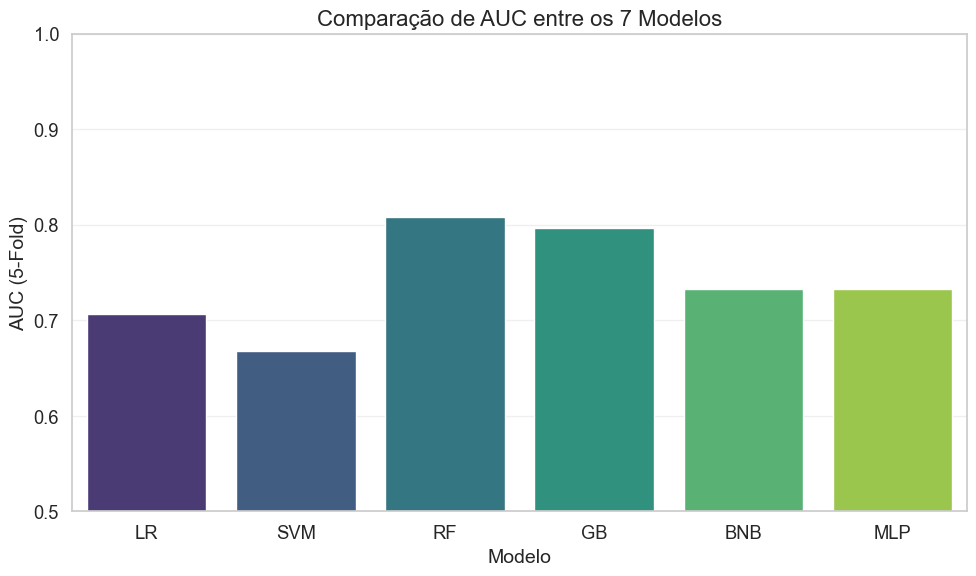


 Figura salva em: 5fold_PK/auc_comparacao_7modelos_PK.png


In [ ]:

sns.set(style="whitegrid", font_scale=1.2)

models_james_PK = ['LR', 'SVM', 'RF', 'GB']
means_james_PK = [lr_mean_PK, svm_mean_PK, rf_mean_PK, gb_mean_PK]
aucs_james_PK = [lr_auc_PK, svm_auc_PK, rf_auc_PK, gb_auc_PK]

cv_james_list_PK = []
for name_PK, mean_res_PK, auc_vals_PK in zip(models_james_PK, means_james_PK, aucs_james_PK):
    cv_james_list_PK.append({
        'Model': name_PK,
        'Accuracy': mean_res_PK[0],
        'Sensitivity': mean_res_PK[1],
        'Specificity': mean_res_PK[2],
        'PPV': mean_res_PK[7],
        'NPV': mean_res_PK[8],
        'AUC': np.mean(auc_vals_PK)
    })

df_james_PK = pd.DataFrame(cv_james_list_PK).round(3)

print("\n=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===")
display(df_james_PK)

models_new_PK = ['BNB', 'MLP']
means_new_PK = [bnb_mean_PK, mlp_mean_PK]
aucs_new_PK = [ bnb_mean_PK,  mlp_auc_PK]

cv_new_list_PK = []
for name_PK, mean_res_PK, auc_vals_PK in zip(models_new_PK, means_new_PK, aucs_new_PK):
    cv_new_list_PK.append({
        'Model': name_PK,
        'Accuracy': mean_res_PK[0],
        'Sensitivity': mean_res_PK[1],
        'Specificity': mean_res_PK[2],
        'PPV': mean_res_PK[7],
        'NPV': mean_res_PK[8],
        'AUC': np.mean(auc_vals_PK)
    })

df_new_PK = pd.DataFrame(cv_new_list_PK).round(3)

print("\n=== MODELOS NOVOS — 5-FOLD ===")
display(df_new_PK)

df_all_PK = pd.concat([df_james_PK, df_new_PK], ignore_index=True)
df_all_PK = df_all_PK[['Model', 'Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'AUC']]

print("\n=== TABELA FINAL — TODOS OS MODELOS ===")
display(df_all_PK)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_all_PK, x='Model', y='AUC', palette='viridis')

plt.title("Comparação de AUC entre os 7 Modelos", fontsize=16)
plt.ylabel("AUC (5-Fold)", fontsize=14)
plt.xlabel("Modelo", fontsize=14)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Figura salva em: 5fold_PK/auc_comparacao_7modelos_PK.png")

In [ ]:



cv_summary_PK = pd.DataFrame({
    'Model': ['LR', 'SVM', 'RF', 'GB', 'BNB', 'MLP'],

    'Accuracy': [
        lr_mean_PK[0], svm_mean_PK[0], rf_mean_PK[0], gb_mean_PK[0],bnb_mean_PK[0], mlp_mean_PK[0]
    ],

    'Sensitivity (Recall)': [
        lr_mean_PK[1], svm_mean_PK[1], rf_mean_PK[1], gb_mean_PK[1],bnb_mean_PK[0], mlp_mean_PK[1]
    ],

    'Specificity': [
        lr_mean_PK[2], svm_mean_PK[2], rf_mean_PK[2], gb_mean_PK[2],bnb_mean_PK[0], mlp_mean_PK[2]
    ],

    'PPV (Precision)': [
        lr_mean_PK[7], svm_mean_PK[7], rf_mean_PK[7], gb_mean_PK[7],bnb_mean_PK[0], mlp_mean_PK[7]
    ],

    'NPV': [
        lr_mean_PK[8], svm_mean_PK[8], rf_mean_PK[8], gb_mean_PK[8],bnb_mean_PK[0], mlp_mean_PK[8]
    ],

    'AUC': [
        np.mean(lr_auc_PK), np.mean(svm_auc_PK), np.mean(rf_auc_PK), np.mean(gb_auc_PK),np.mean(bnb_auc_PK),np.mean(mlp_auc_PK)
    ]
}).round(3)

print("\n=== MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS ===")
display(cv_summary_PK)


=== MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS ===


,Model,Accuracy,Sensitivity (Recall),Specificity,PPV (Precision),NPV,AUC
0,LR,0.783,0.419,0.847,0.333,0.892,0.707
1,SVM,0.775,0.306,0.858,0.284,0.875,0.668
2,RF,0.836,0.262,0.938,0.479,0.878,0.808
3,GB,0.850,0.150,0.975,0.523,0.866,0.796
4,BNB,0.730,0.730,0.730,0.730,0.730,0.773
5,MLP,0.802,0.275,0.896,0.322,0.875,0.733


### Análises Pós-Modelagem (Exploratórias)

In [ ]:


sns.set(style="whitegrid", font_scale=1.2)

def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


lr_auc_PK, lr_metrics_PK, lr_models_PK, lr_err_PK, lr_feat_PK, lr_probs_PK, lr_preds_PK, vars_lr = load_results("5fold_PK/lr_results_PK.pkl")

svm_auc_PK, svm_metrics_PK, svm_models_PK, svm_err_PK, svm_feat_PK, svm_probs_PK, svm_preds_PK, vars_svm = load_results("5fold_PK/svm_results_PK.pkl")

rf_auc_PK, rf_metrics_PK, rf_models_PK, rf_err_PK, rf_feat_PK, rf_probs_PK, rf_preds_PK, vars_rf = load_results("5fold_PK/rf_results_PK.pkl")

gb_auc_PK, gb_metrics_PK, gb_models_PK, gb_err_PK, gb_feat_PK, gb_probs_PK, gb_preds_PK, vars_gb = load_results("5fold_PK/gb_results_PK.pkl")



bnb_auc_PK, bnb_metrics_PK, bnb_models_PK, bnb_err_PK, bnb_feat_PK, bnb_probs_PK, bnb_preds_PK, vars_bnb = load_results("5fold_PK/bnb_results_PK.pkl")

mlp_auc_PK, mlp_metrics_PK, mlp_models_PK, mlp_err_PK, mlp_feat_PK, mlp_probs_PK, mlp_preds_PK, vars_mlp = load_results("5fold_PK/mlp_results_PK.pkl")

final_variable_names_PK = vars_lr



--- Análise de Importância das Features (Média dos 5 Folds) ---


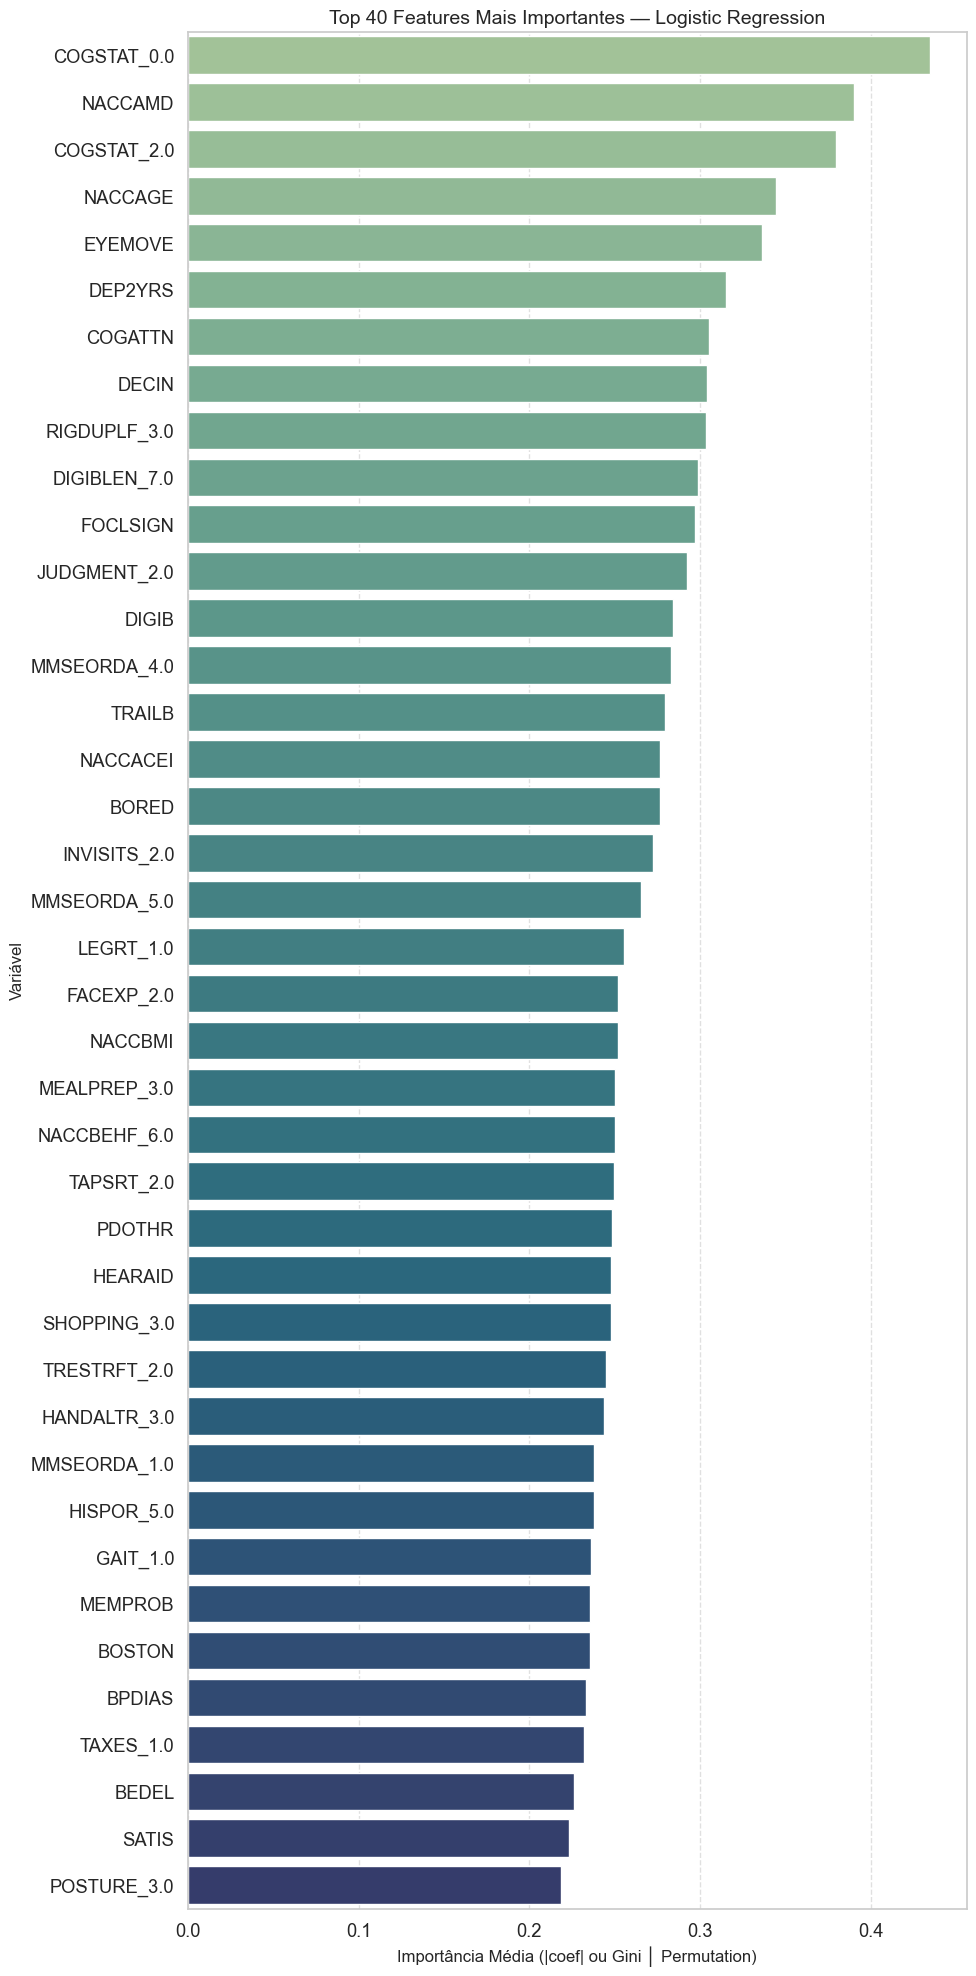

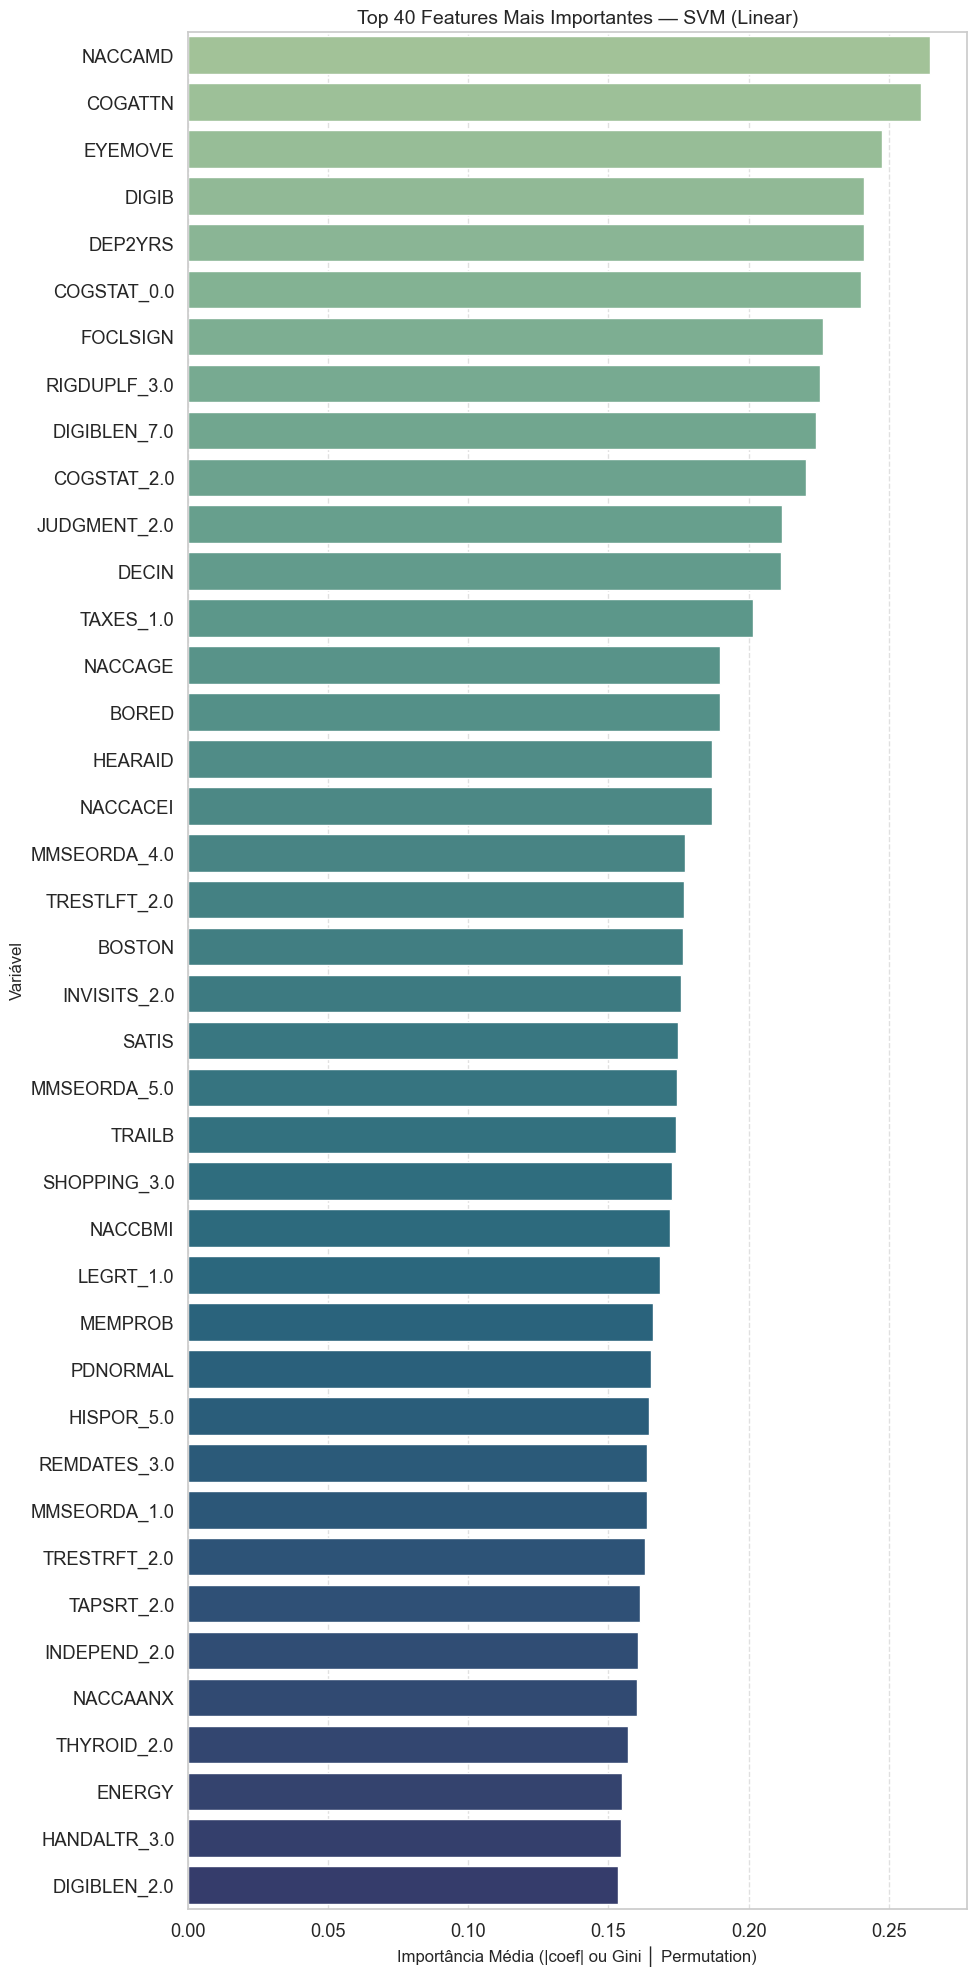

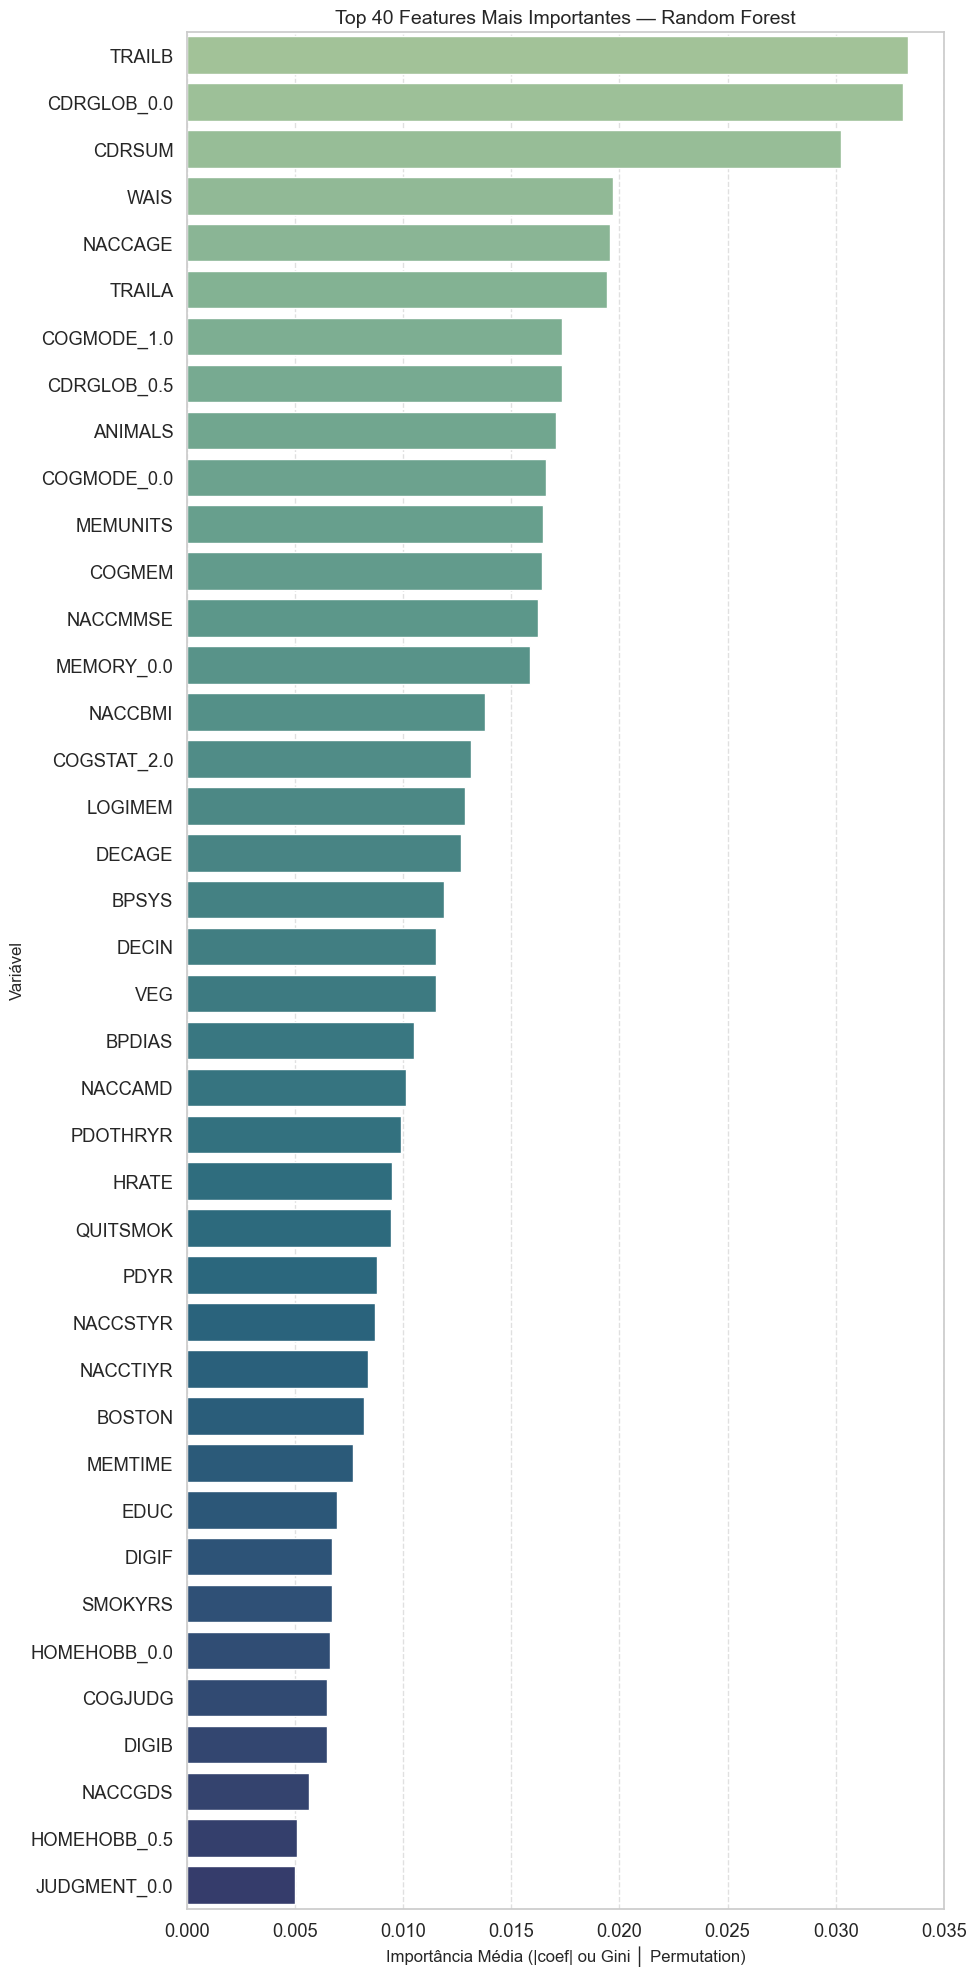

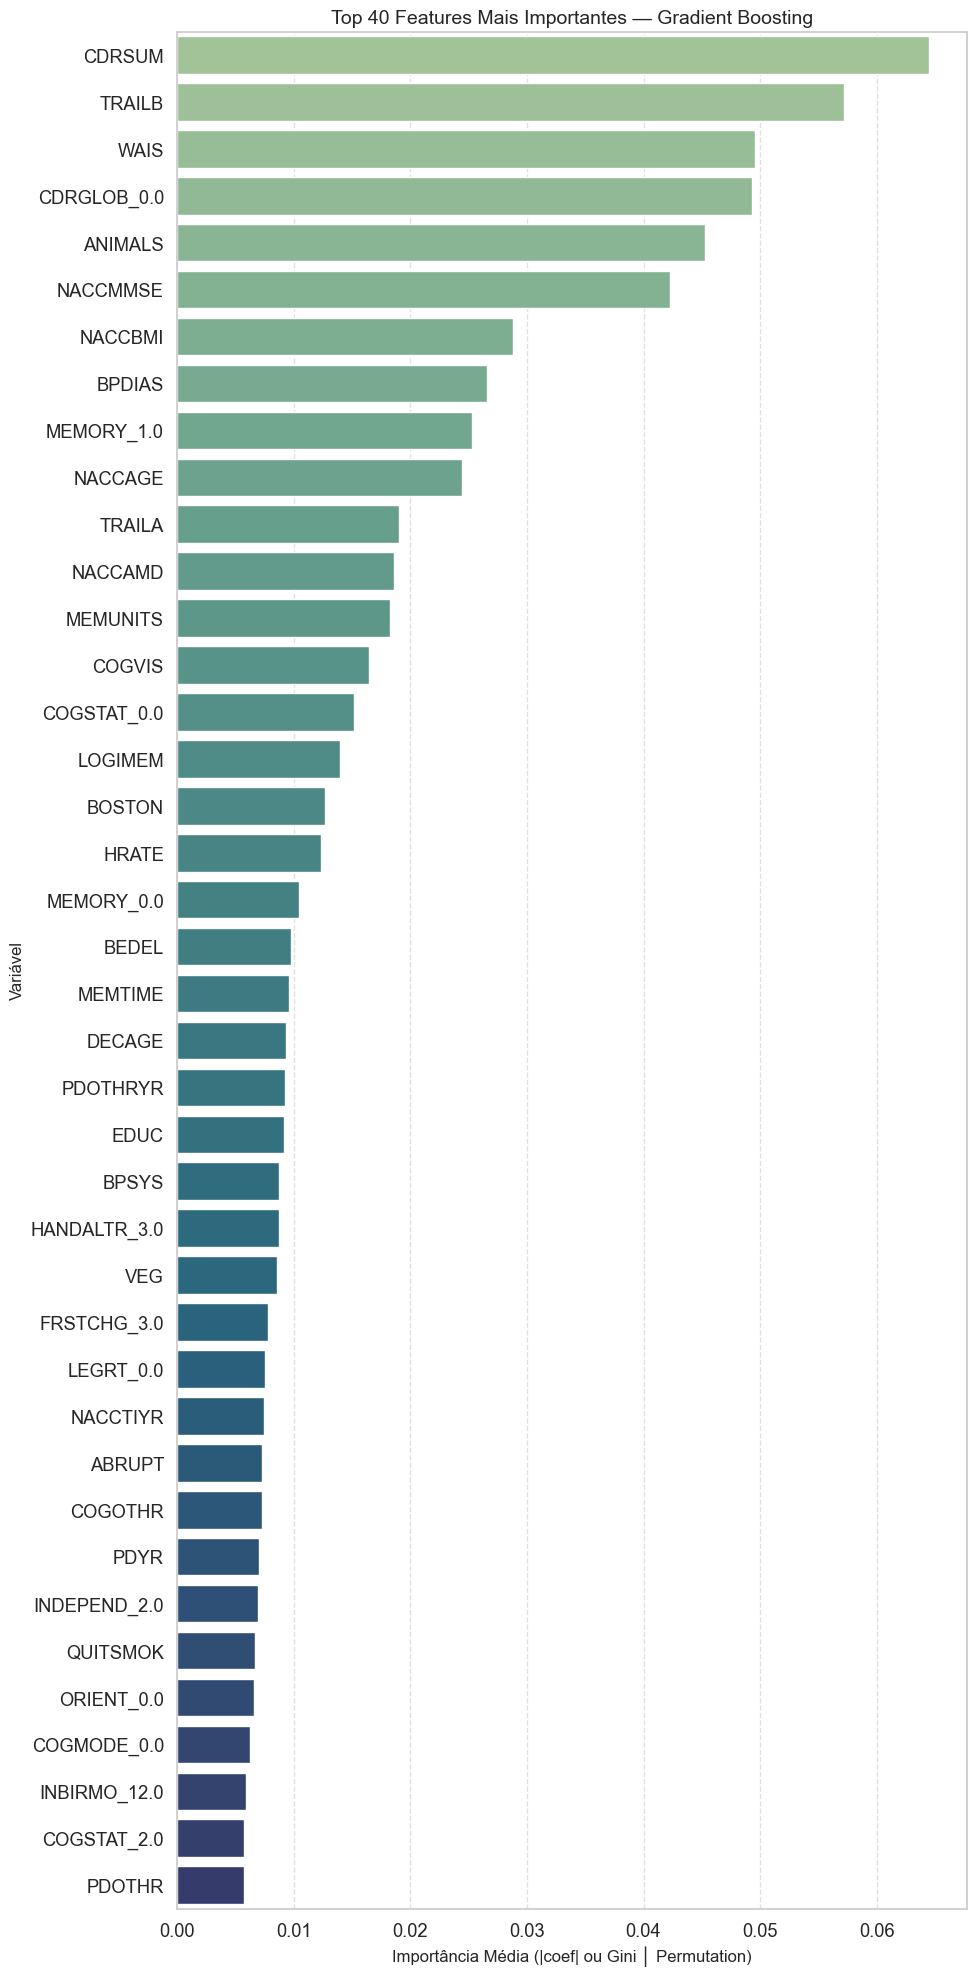

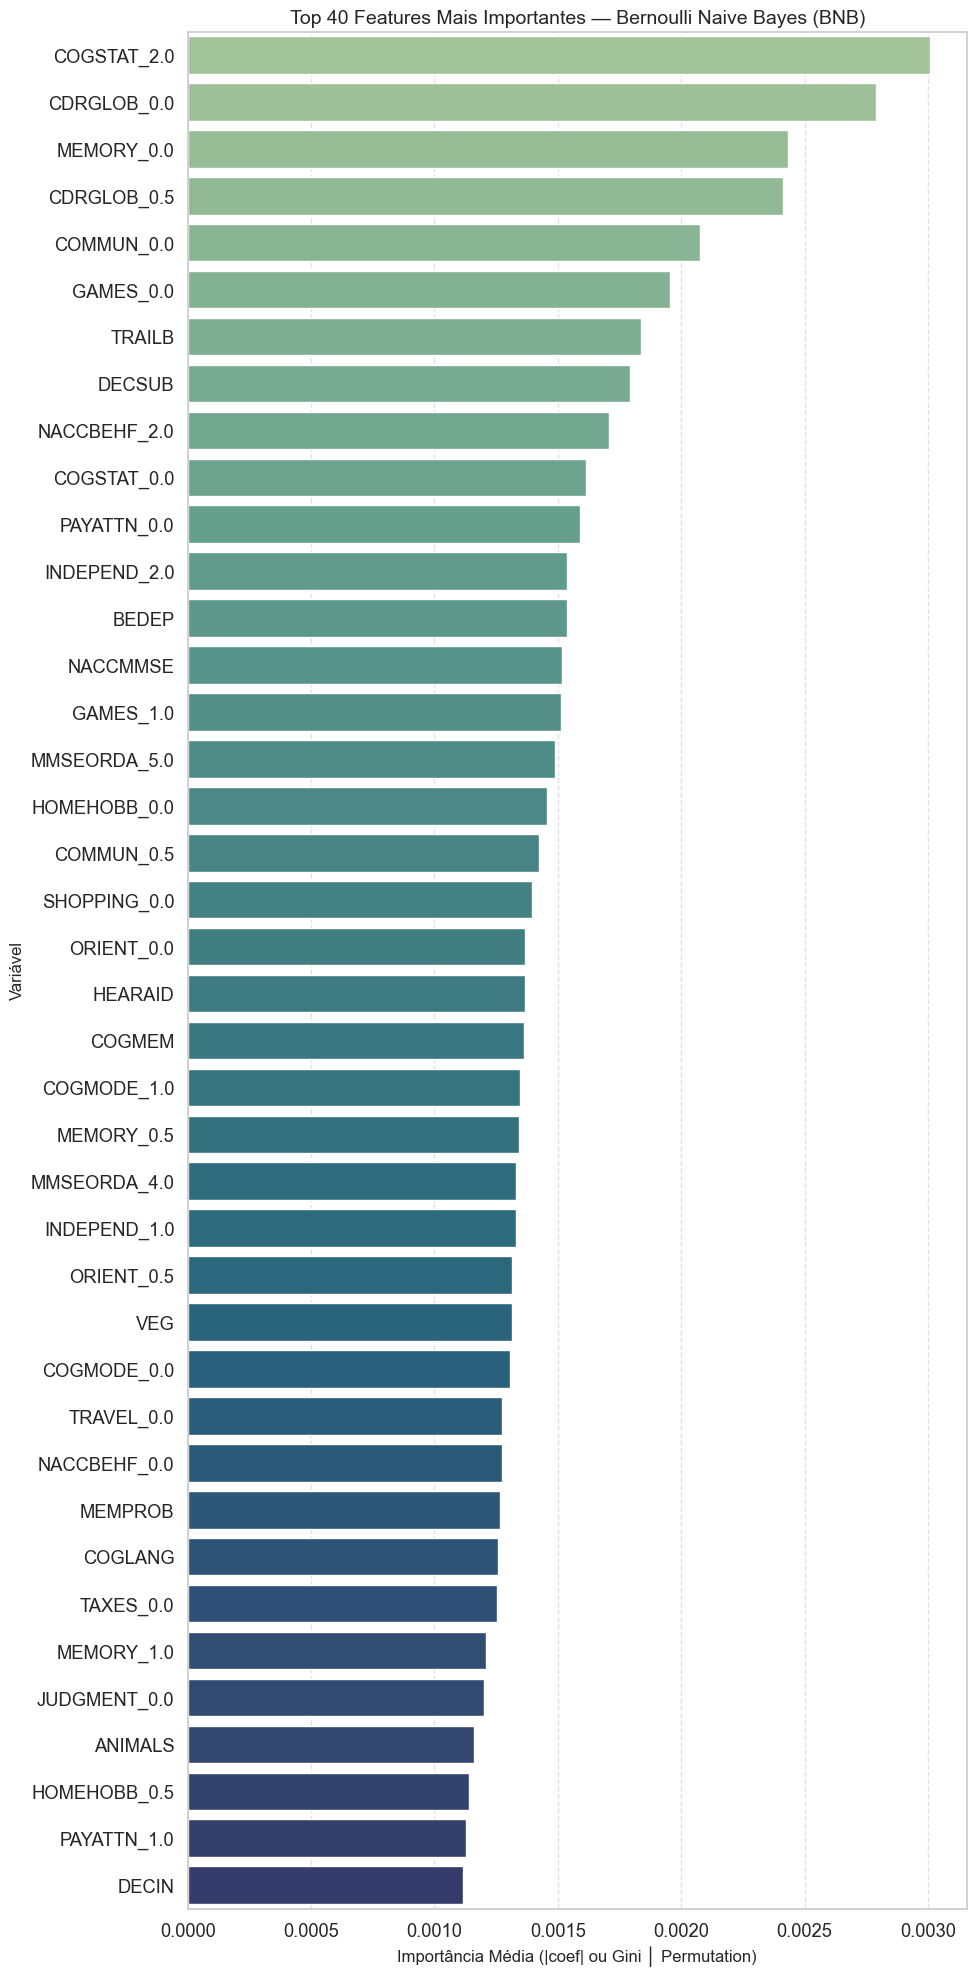

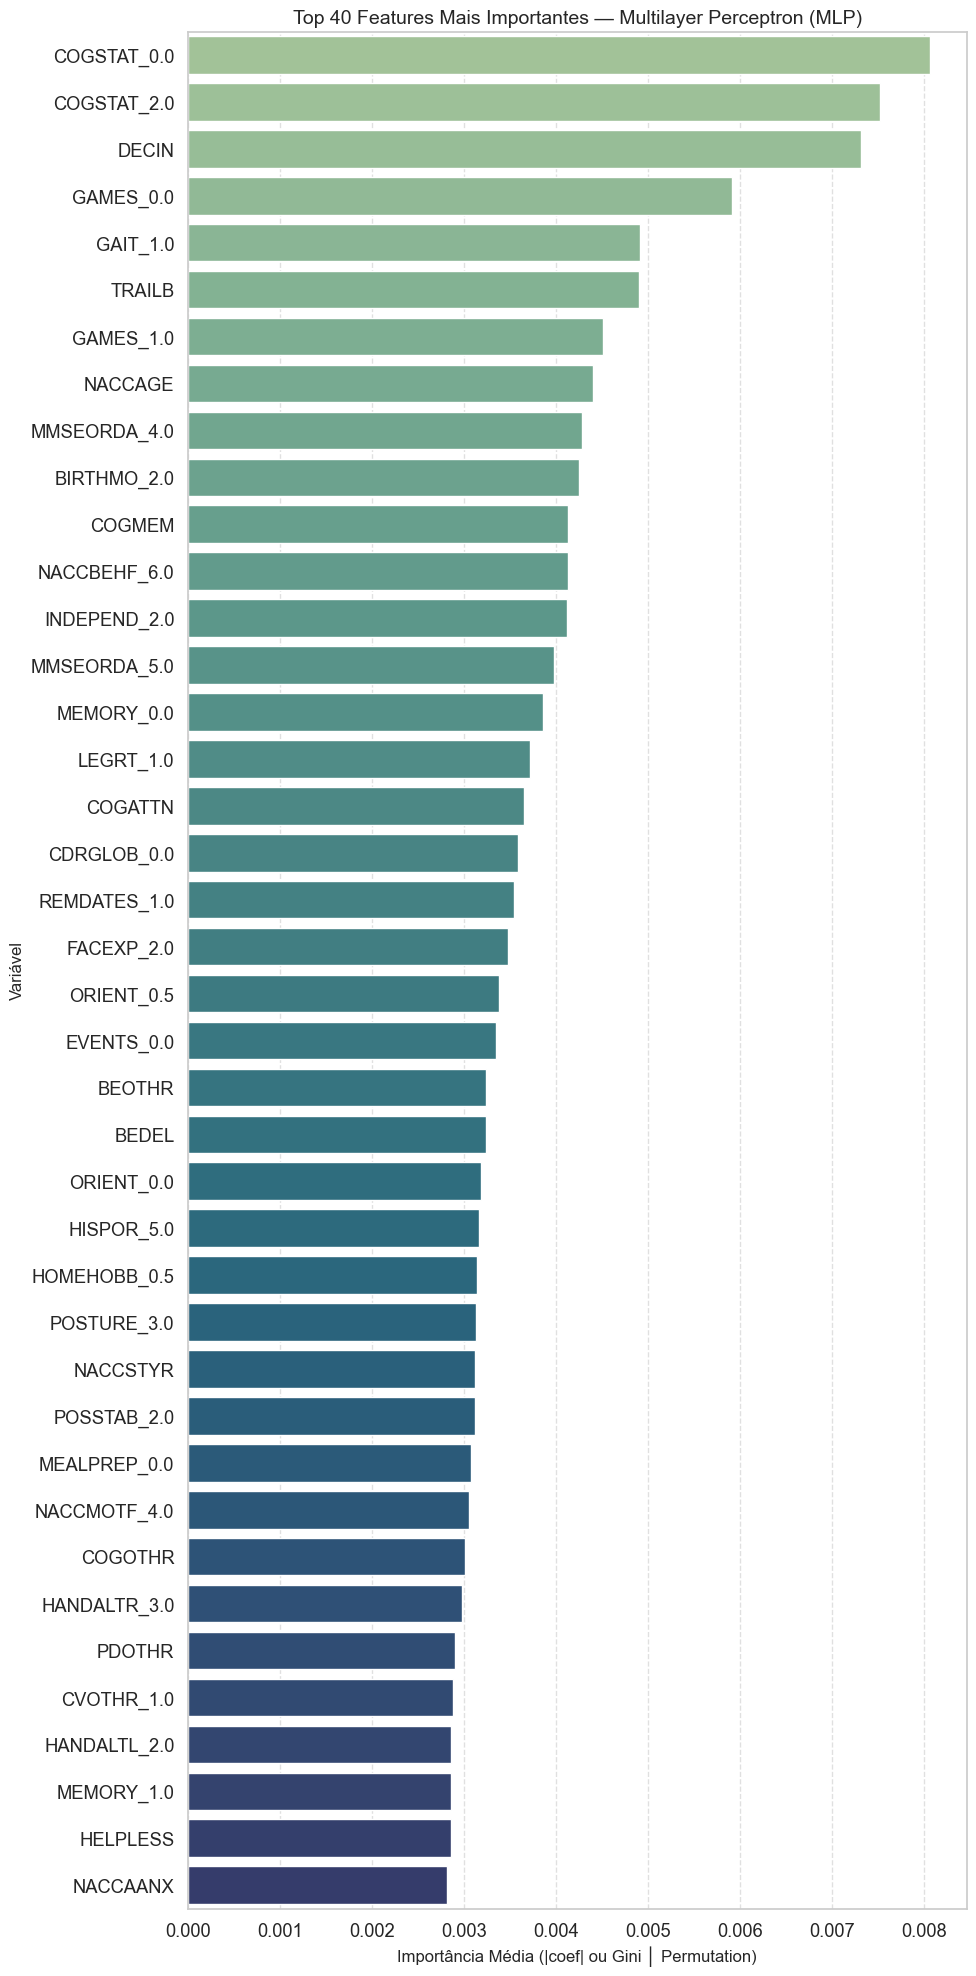

In [80]:
def analyze_and_plot_feature_importance_PK(model_name_PK, feature_importances_list_PK, variable_names_PK, top_n_PK=40):
    feature_importances_array_PK = np.array(feature_importances_list_PK, dtype=float)
    if feature_importances_array_PK.ndim == 1:
        feature_importances_array_PK = feature_importances_array_PK.reshape(1, -1)

    mean_importances_PK = np.nanmean(np.abs(feature_importances_array_PK), axis=0)

    if np.all(np.isnan(mean_importances_PK)):
        print(f"Não foi possível calcular a importância média para {model_name_PK}.")
        return None

    feature_importance_df_PK = (
        pd.DataFrame({'Feature': variable_names_PK, 'Importance': mean_importances_PK})
        .sort_values(by='Importance', ascending=False)
        .head(top_n_PK)
    )

    plt.figure(figsize=(10, max(6, top_n_PK // 2)))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df_PK, palette='crest')
    plt.title(f'Top {top_n_PK} Features Mais Importantes — {model_name_PK}', fontsize=14)
    plt.xlabel('Importância Média (|coef| ou Gini │ Permutation)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return feature_importance_df_PK


print("\n--- Análise de Importância das Features (Média dos 5 Folds) ---")


top_lr_features_PK = analyze_and_plot_feature_importance_PK(
    'Logistic Regression', lr_feat_PK, final_variable_names_PK
)

top_svm_features_PK = analyze_and_plot_feature_importance_PK(
    'SVM (Linear)', svm_feat_PK, final_variable_names_PK
)

top_rf_features_PK = analyze_and_plot_feature_importance_PK(
    'Random Forest', rf_feat_PK, final_variable_names_PK
)

top_gb_features_PK = analyze_and_plot_feature_importance_PK(
    'Gradient Boosting', gb_feat_PK, final_variable_names_PK
)


top_bnb_features_PK = analyze_and_plot_feature_importance_PK(
    'Bernoulli Naive Bayes (BNB)', bnb_feat_PK, final_variable_names_PK
) 

top_mlp_features_PK = analyze_and_plot_feature_importance_PK(
    'Multilayer Perceptron (MLP)', mlp_feat_PK, final_variable_names_PK
)

In [81]:
os.chdir('./5fold_PK/')  

In [ ]:


def load_data_PK(model_PK):
    with open(f'../5fold_PK/{model_PK}_results_PK.pkl', 'rb') as f_PK:
        auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK, variables_PK = pkl.load(f_PK)
    return auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK, variables_PK


print(" Carregando resultados dos modelos...\n")

rf_auc_PK, rf_metrics_PK, rf_models_PK, rf_err_PK, rf_feat_PK, rf_probs_PK, rf_preds_PK, variables_PK = load_data_PK('rf')
lr_auc_PK, lr_metrics_PK, lr_models_PK, lr_err_PK, lr_feat_PK, lr_probs_PK, lr_preds_PK, _ = load_data_PK('lr')
svm_auc_PK, svm_metrics_PK, svm_models_PK, svm_err_PK, svm_feat_PK, svm_probs_PK, svm_preds_PK, _ = load_data_PK('svm')
gb_auc_PK, gb_metrics_PK, gb_models_PK, gb_err_PK, gb_feat_PK, gb_probs_PK, gb_preds_PK, _ = load_data_PK('gb')

bnb_auc_PK, bnb_metrics_PK, bnb_models_PK, bnb_err_PK, bnb_feat_PK, bnb_probs_PK, bnb_preds_PK, _ = load_data_PK('bnb')
mlp_auc_PK, mlp_metrics_PK, mlp_models_PK, mlp_err_PK, mlp_feat_PK, mlp_probs_PK, mlp_preds_PK, _ = load_data_PK('mlp')

print(" Todos os modelos carregados com sucesso!")

 Carregando resultados dos modelos...

 Todos os modelos carregados com sucesso!


In [ ]:

data_PK = np.load('../encoded_data_PK.npy')
outcome_PK = np.load('../outcome_PK.npy')

sk_PK = skf(n_splits=5)

true_PK = []
for train_PK, test_PK in sk_PK.split(data_PK, outcome_PK):
    true_PK.extend(outcome_PK[test_PK])
true_PK = np.array(true_PK)

print(f"Array de rótulos verdadeiros (true_PK) criado com shape: {true_PK.shape}")

Array de rótulos verdadeiros (true_PK) criado com shape: (1063,)


 Diretório de execução: /Users/eduardafigueredo/NACC PARKINSON
 Carregando probabilidades...
 Probabilidades carregadas!
Vetor verdadeiro reconstruído (1063 entradas)


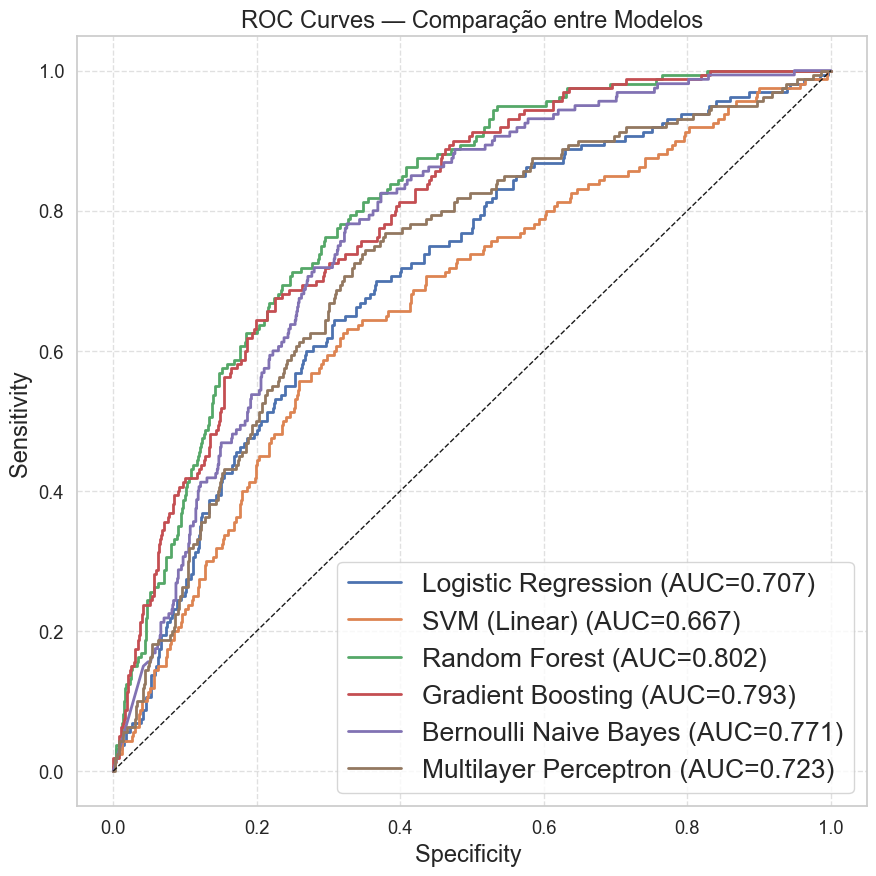

 Figura salva em 5fold_PK/compare_auc_roc_models_PK.svg


In [ ]:


sns.set(style="whitegrid", font_scale=1.2)


if os.path.basename(os.getcwd()) == "5fold_PK":
    os.chdir("..")
print(" Diretório de execução:", os.getcwd())


def load_probs_PK(model_PK):
    with open(f'5fold_PK/{model_PK}_results_PK.pkl', 'rb') as f_PK:
        auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK, _vars_PK = pkl.load(f_PK)
    return np.array(probs_PK)

print(" Carregando probabilidades...")

probs_lr_PK = load_probs_PK('lr')
probs_svm_PK = load_probs_PK('svm')
probs_rf_PK = load_probs_PK('rf')
probs_gb_PK = load_probs_PK('gb')
probs_bnb_PK = load_probs_PK('bnb')
probs_mlp_PK = load_probs_PK('mlp')

print(" Probabilidades carregadas!")


def rebuild_true_vector_PK(outcome_PK, n_splits_PK=5):
    sk_PK = skf(n_splits=n_splits_PK, shuffle=True, random_state=42)
    true_concat_PK = []
    for _, test_idx_PK in sk_PK.split(np.zeros_like(outcome_PK), outcome_PK):
        true_concat_PK.extend(outcome_PK[test_idx_PK])
    return np.array(true_concat_PK)

outcome_PK = np.load("outcome_PK.npy")
true_all_PK = rebuild_true_vector_PK(outcome_PK)

print(f"Vetor verdadeiro reconstruído ({len(true_all_PK)} entradas)")


def plot_roc_PK(probs_list_PK, true_list_PK, labels_PK):
    plt.figure(figsize=(9, 9))

    for prob_PK, label_PK in zip(probs_list_PK, labels_PK):
        fpr_PK, tpr_PK, _ = roc_curve(true_list_PK, prob_PK)
        auc_val_PK = roc_auc_score(true_list_PK, prob_PK)
        plt.plot(fpr_PK, tpr_PK, linewidth=2, label=f"{label_PK} (AUC={auc_val_PK:.3f})")

    xx_PK = np.linspace(0, 1, 100)
    plt.plot(xx_PK, xx_PK, 'k--', linewidth=1)

    plt.xlabel("Specificity ", fontsize=17)
    plt.ylabel("Sensitivity ", fontsize=17)
    plt.title("ROC Curves — Comparação entre Modelos", fontsize=17)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(
    loc='lower right',
    fontsize=19,           
    title_fontsize=21,     
)
    plt.tight_layout()

    plt.savefig("5fold_PK/compare_auc_roc_models_PK.svg", dpi=300)
    plt.show()
    print(" Figura salva em 5fold_PK/compare_auc_roc_models_PK.svg")


probs_PK = [
    probs_lr_PK,
    probs_svm_PK,
    probs_rf_PK,
    probs_gb_PK, 
    probs_bnb_PK,
    probs_mlp_PK
]

labels_PK = [
    "Logistic Regression",
    "SVM (Linear)",
    "Random Forest",
    "Gradient Boosting",
    "Bernoulli Naive Bayes",
    "Multilayer Perceptron"
]

plot_roc_PK(probs_PK, true_all_PK, labels_PK)

 Diretório atual: /Users/eduardafigueredo/NACC PARKINSON

=== RF ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/rf_auc_low_hi_med_PK.npy


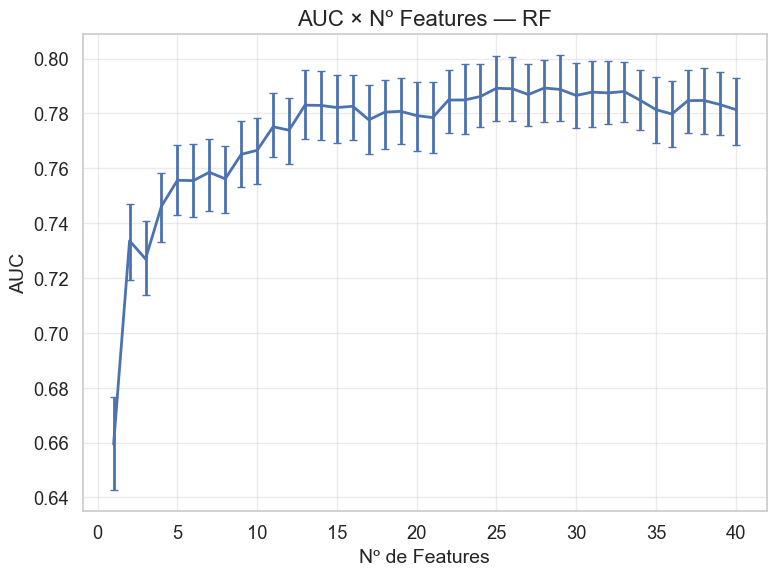

 Gráfico salvo: 5fold_PK/rf_auc_vs_features_PK.png

=== LR ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/lr_auc_low_hi_med_PK.npy


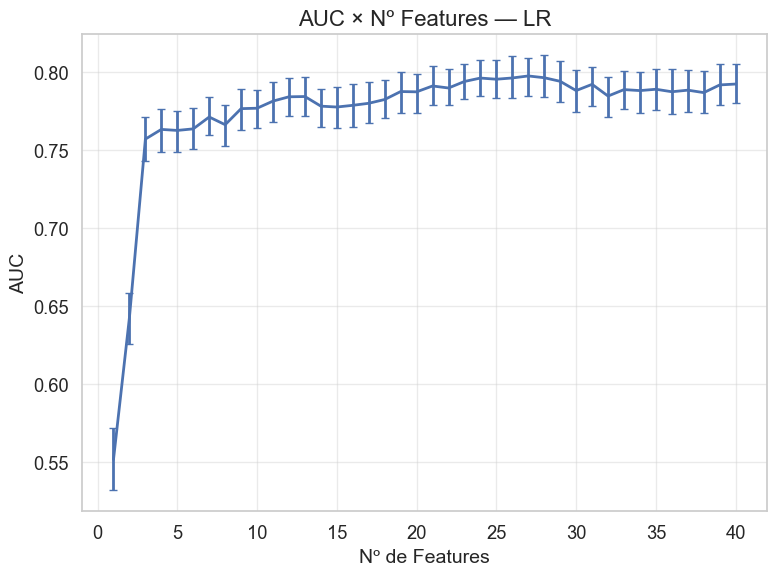

 Gráfico salvo: 5fold_PK/lr_auc_vs_features_PK.png

=== SVM ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/svm_auc_low_hi_med_PK.npy


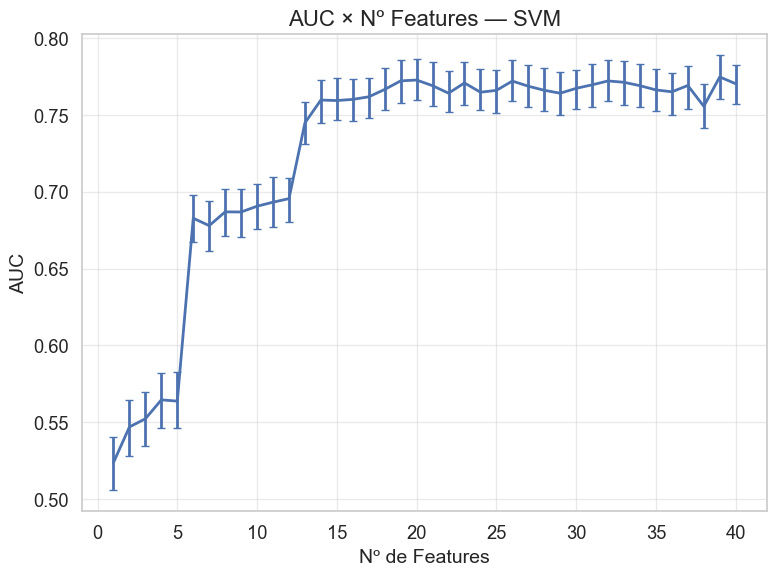

 Gráfico salvo: 5fold_PK/svm_auc_vs_features_PK.png

=== GB ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/gb_auc_low_hi_med_PK.npy


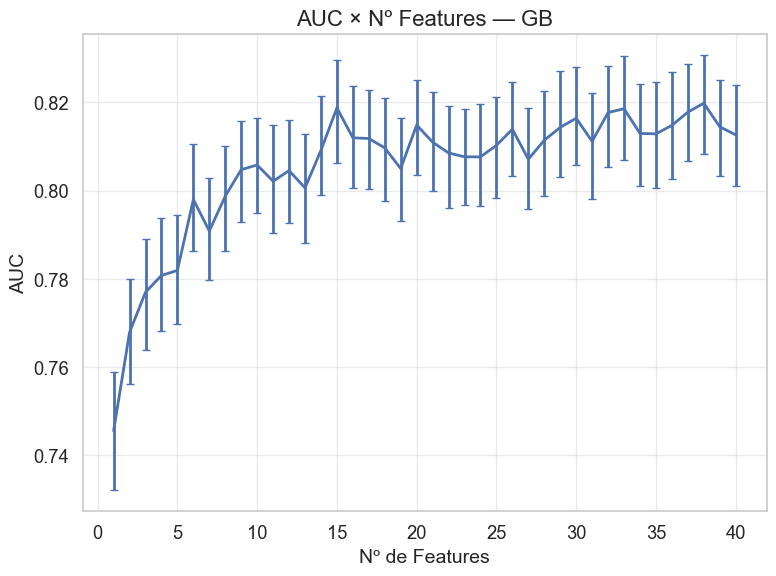

 Gráfico salvo: 5fold_PK/gb_auc_vs_features_PK.png

=== BNB ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/bnb_auc_low_hi_med_PK.npy


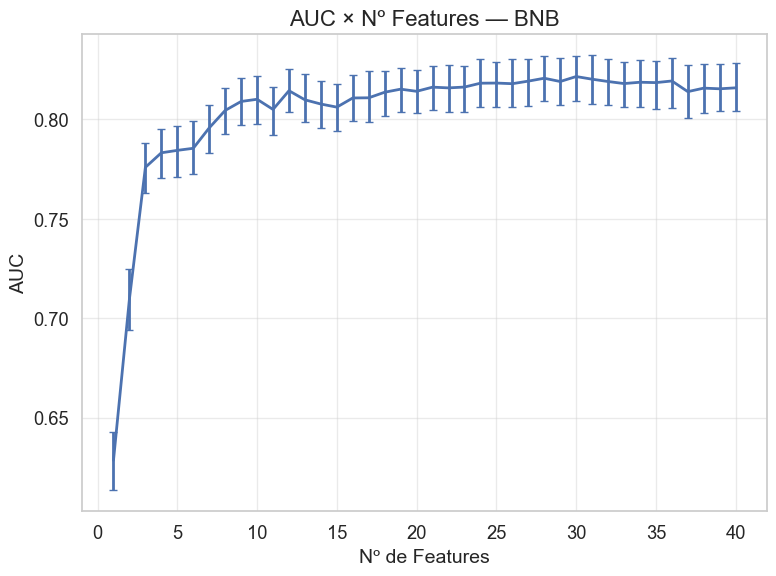

 Gráfico salvo: 5fold_PK/bnb_auc_vs_features_PK.png

=== MLP ===
→ nº de modelos carregados: 5
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
 Salvo: 5fold_PK/mlp_auc_low_hi_med_PK.npy


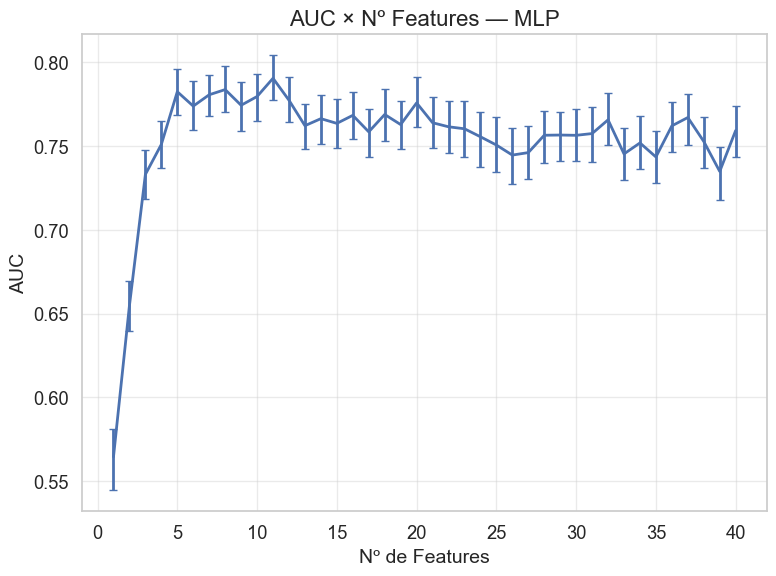

 Gráfico salvo: 5fold_PK/mlp_auc_vs_features_PK.png


In [85]:
os.makedirs("5fold_PK", exist_ok=True)
print(" Diretório atual:", os.getcwd())


def bootstrap_auc_PK(probability_PK, classes_PK, n_iter_PK=1000, sample_size_PK=1000):
    probability_PK = np.array(probability_PK)
    classes_PK = np.array(classes_PK)

    auc_vals_PK = []
    n_PK = len(classes_PK)

    for _ in range(n_iter_PK):
        idx_PK = np.random.randint(0, n_PK, size=min(sample_size_PK, n_PK))
        auc_vals_PK.append(
            roc_auc_score(classes_PK[idx_PK], probability_PK[idx_PK])
        )

    return (
        np.percentile(auc_vals_PK, 25),
        np.percentile(auc_vals_PK, 75),
        np.median(auc_vals_PK)
    )



def auc_feat_PK(models_PK, feat_importance_PK, X_data_PK, y_data_PK, n_features_PK=40):

    idx_PK = np.argsort(-feat_importance_PK)
    sk_PK = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_vals_PK, lows_PK, highs_PK, meds_PK = [], [], [], []

    if len(models_PK) == 1:
        print("Apenas 1 modelo encontrado — replicando para 5 folds")
        models_PK = models_PK * 5

    for k_PK in range(1, n_features_PK + 1):

        print(f"{k_PK} features...")

        feats_PK = idx_PK[:k_PK]
        probs_PK, true_PK = [], []
        fold_PK = 0

        for train_idx_PK, test_idx_PK in sk_PK.split(X_data_PK, y_data_PK):

            model_PK = models_PK[fold_PK]

            X_train_PK = X_data_PK[train_idx_PK][:, feats_PK]
            X_test_PK  = X_data_PK[test_idx_PK][:, feats_PK]
            y_train_PK = y_data_PK[train_idx_PK]
            y_test_PK  = y_data_PK[test_idx_PK]

            model_PK.fit(X_train_PK, y_train_PK)

            if hasattr(model_PK, "predict_proba"):
                prob_PK = model_PK.predict_proba(X_test_PK)[:, 1]
            else:
                dec_PK = model_PK.decision_function(X_test_PK)
                prob_PK = (dec_PK - dec_PK.min()) / (dec_PK.max() - dec_PK.min() + 1e-9)

            probs_PK.extend(prob_PK)
            true_PK.extend(y_test_PK)

            fold_PK += 1

        auc_val_PK = roc_auc_score(true_PK, probs_PK)
        l_PK, h_PK, m_PK = bootstrap_auc_PK(probs_PK, true_PK)

        auc_vals_PK.append(auc_val_PK)
        lows_PK.append(l_PK)
        highs_PK.append(h_PK)
        meds_PK.append(m_PK)

    return auc_vals_PK, lows_PK, meds_PK, highs_PK




models_info_PK = {
    "rf":  "5fold_PK/rf_results_PK.pkl",
    "lr":  "5fold_PK/lr_results_PK.pkl",
    "svm": "5fold_PK/svm_results_PK.pkl",
    "gb":  "5fold_PK/gb_results_PK.pkl",
    "bnb": "5fold_PK/bnb_results_PK.pkl",
    "mlp": "5fold_PK/mlp_results_PK.pkl",
}

X_final_PK = np.load("encoded_data_PK.npy")
y_final_PK = np.load("outcome_PK.npy")


for short_PK, pkl_path_PK in models_info_PK.items():

    print(f"\n=== {short_PK.upper()} ===")

    with open(pkl_path_PK, "rb") as f:
        data_PK = pickle.load(f)

    feat_PK   = data_PK[4]              
    models_PK = data_PK[2]               
    if not isinstance(models_PK, list):
        models_PK = [models_PK]

    print(f"→ nº de modelos carregados: {len(models_PK)}")

    mean_feat_PK = np.mean(feat_PK, axis=0)

    if len(mean_feat_PK) > X_final_PK.shape[1]:
        print(f"⚠ Ajustando feat_importance: {len(mean_feat_PK)} → {X_final_PK.shape[1]}")
        mean_feat_PK = mean_feat_PK[:X_final_PK.shape[1]]

    a_PK, l_PK, m_PK, h_PK = auc_feat_PK(models_PK, mean_feat_PK, X_final_PK, y_final_PK, n_features_PK=40)

    save_path_PK = f"5fold_PK/{short_PK}_auc_low_hi_med_PK.npy"
    np.save(save_path_PK, [a_PK, l_PK, m_PK, h_PK])

    print(f" Salvo: {save_path_PK}")

    x_PK = list(range(1, 41))
    plt.figure(figsize=(8, 6))
    plt.errorbar(
        x_PK, m_PK,
        yerr=np.vstack((np.array(m_PK) - np.array(l_PK), np.array(h_PK) - np.array(m_PK))),
        capsize=3, linewidth=2
    )
    plt.xlabel("Nº de Features", fontsize=14)
    plt.ylabel("AUC", fontsize=14)
    plt.title(f"AUC × Nº Features — {short_PK.upper()}", fontsize=16)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    img_path_PK = f"5fold_PK/{short_PK}_auc_vs_features_PK.png"
    plt.savefig(img_path_PK, dpi=300)
    plt.show()

    print(f" Gráfico salvo: {img_path_PK}")


 Carregando importâncias...
 Importâncias carregadas com sucesso!

Top 40 variáveis por modelo extraídas:


,LR,SVM,RF,GB,BNB,MLP
0,COGSTAT_0.0,NACCAMD,TRAILB,CDRSUM,COGSTAT_2.0,COGSTAT_0.0
1,NACCAMD,COGATTN,CDRGLOB_0.0,TRAILB,CDRGLOB_0.0,COGSTAT_2.0
2,COGSTAT_2.0,EYEMOVE,CDRSUM,WAIS,MEMORY_0.0,DECIN
3,NACCAGE,DIGIB,WAIS,CDRGLOB_0.0,CDRGLOB_0.5,GAMES_0.0
4,EYEMOVE,DEP2YRS,NACCAGE,ANIMALS,COMMUN_0.0,GAIT_1.0
5,DEP2YRS,COGSTAT_0.0,TRAILA,NACCMMSE,GAMES_0.0,TRAILB
6,COGATTN,FOCLSIGN,COGMODE_1.0,NACCBMI,TRAILB,GAMES_1.0
7,DECIN,RIGDUPLF_3.0,CDRGLOB_0.5,BPDIAS,DECSUB,NACCAGE
8,RIGDUPLF_3.0,DIGIBLEN_7.0,ANIMALS,MEMORY_1.0,NACCBEHF_2.0,MMSEORDA_4.0
9,DIGIBLEN_7.0,COGSTAT_2.0,COGMODE_0.0,NACCAGE,COGSTAT_0.0,BIRTHMO_2.0


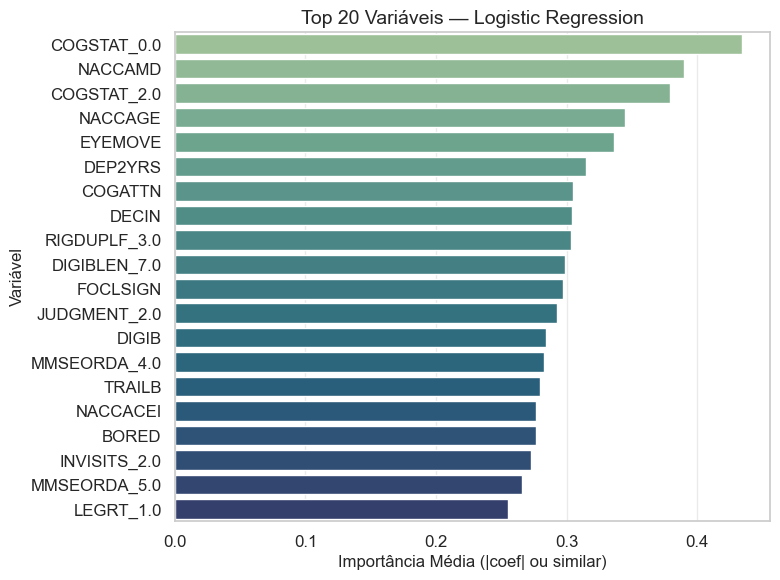

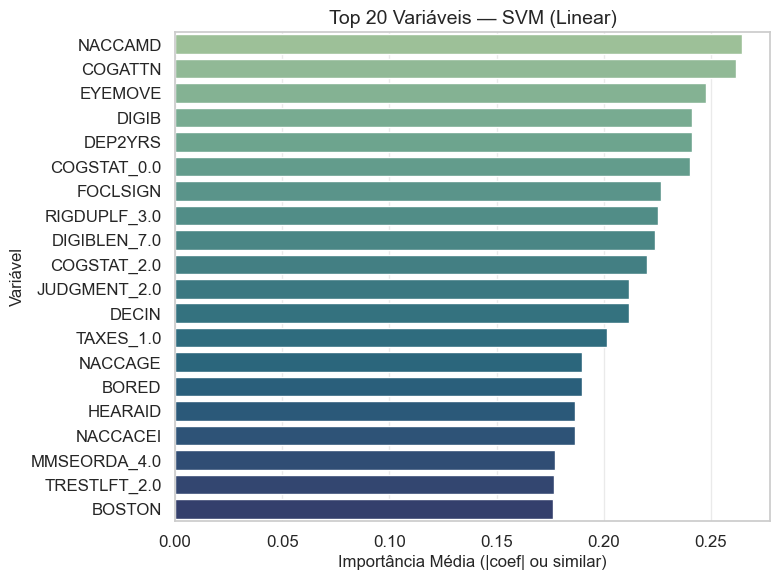

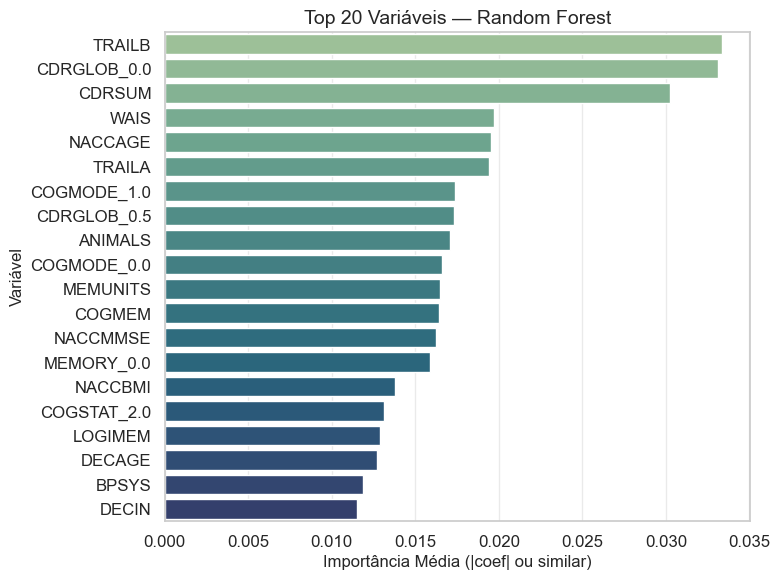

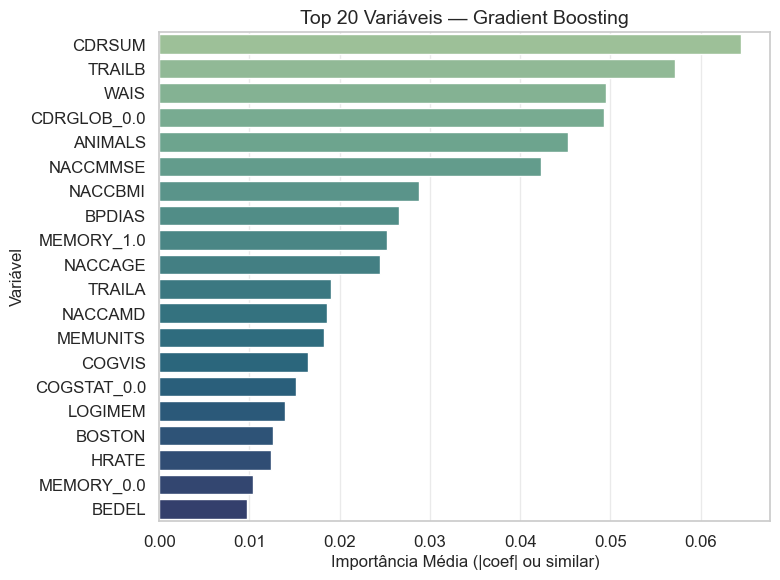

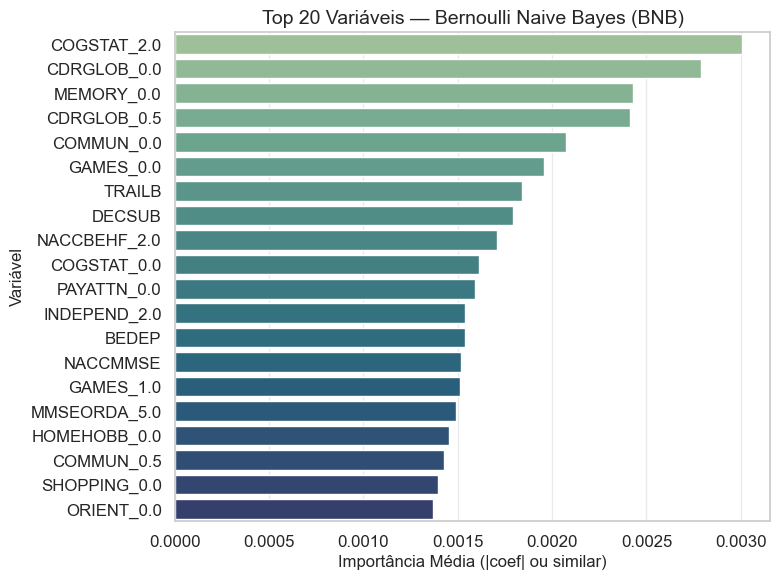

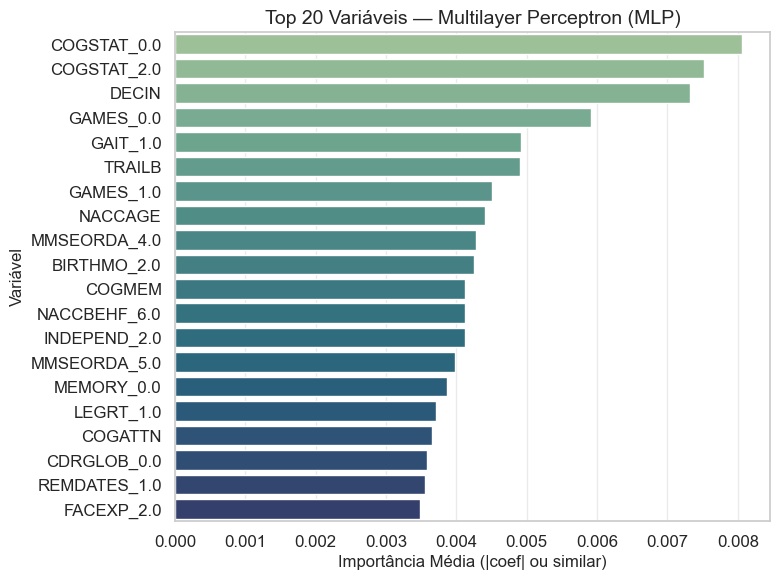

In [ ]:


sns.set(style="whitegrid", font_scale=1.1)

def load_feature_importances_PK(model_PK):
    with open(f'5fold_PK/{model_PK}_results_PK.pkl', 'rb') as f_PK:
        auc_PK, metrics_PK, models_PK, err_PK, feat_PK, probs_PK, preds_PK, variables_PK = pkl.load(f_PK)
    return feat_PK, variables_PK

print(" Carregando importâncias...")

lr_feat_PK, variables_PK = load_feature_importances_PK('lr')
svm_feat_PK, _ = load_feature_importances_PK('svm')
rf_feat_PK, _ = load_feature_importances_PK('rf')
gb_feat_PK, _ = load_feature_importances_PK('gb')
bnb_feat_PK, _ = load_feature_importances_PK('bnb')
mlp_feat_PK, _ = load_feature_importances_PK('mlp')

print(" Importâncias carregadas com sucesso!\n")

def importances_df_PK(models_PK, importances_PK, n_feat_PK, variables_PK):
    features_PK = pd.DataFrame()
    for m_PK, imp_PK in zip(models_PK, importances_PK):
        imp_mean_PK = np.mean(np.abs(imp_PK), axis=0)
        idx_sorted_PK = np.argsort(-imp_mean_PK)
        top_vars_PK = [variables_PK[i_PK] for i_PK in idx_sorted_PK[:n_feat_PK]]
        features_PK[m_PK] = top_vars_PK
    return features_PK


models_PK = ['LR', 'SVM', 'RF', 'GB','BNB', 'MLP']
importances_PK = [lr_feat_PK, svm_feat_PK, rf_feat_PK, gb_feat_PK,bnb_feat_PK, mlp_feat_PK]

features_df_PK = importances_df_PK(models_PK, importances_PK, n_feat_PK=40, variables_PK=variables_PK)

print("Top 40 variáveis por modelo extraídas:")
display(features_df_PK.head(10))

def plot_feature_importance_PK(model_name_PK, feat_list_PK, variables_PK, top_n_PK=20):
    imp_mean_PK = np.mean(np.abs(feat_list_PK), axis=0)
    idx_sorted_PK = np.argsort(-imp_mean_PK)[:top_n_PK]
    top_vars_PK = np.array(variables_PK)[idx_sorted_PK]
    top_scores_PK = imp_mean_PK[idx_sorted_PK]

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_scores_PK, y=top_vars_PK, palette='crest')
    plt.title(f'Top {top_n_PK} Variáveis — {model_name_PK}', fontsize=14)
    plt.xlabel('Importância Média (|coef| ou similar)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_feature_importance_PK('Logistic Regression', lr_feat_PK, variables_PK)
plot_feature_importance_PK('SVM (Linear)', svm_feat_PK, variables_PK)
plot_feature_importance_PK('Random Forest', rf_feat_PK, variables_PK)
plot_feature_importance_PK('Gradient Boosting', gb_feat_PK, variables_PK)
plot_feature_importance_PK('Bernoulli Naive Bayes (BNB)', bnb_feat_PK, variables_PK)
plot_feature_importance_PK('Multilayer Perceptron (MLP)', mlp_feat_PK, variables_PK)

Arquivos encontrados: ['svm_auc_low_hi_med_PK.npy', 'gb_auc_low_hi_med_PK.npy', 'bnb_auc_low_hi_med_PK.npy', 'mlp_auc_low_hi_med_PK.npy', 'lr_auc_low_hi_med_PK.npy', 'rf_auc_low_hi_med_PK.npy']


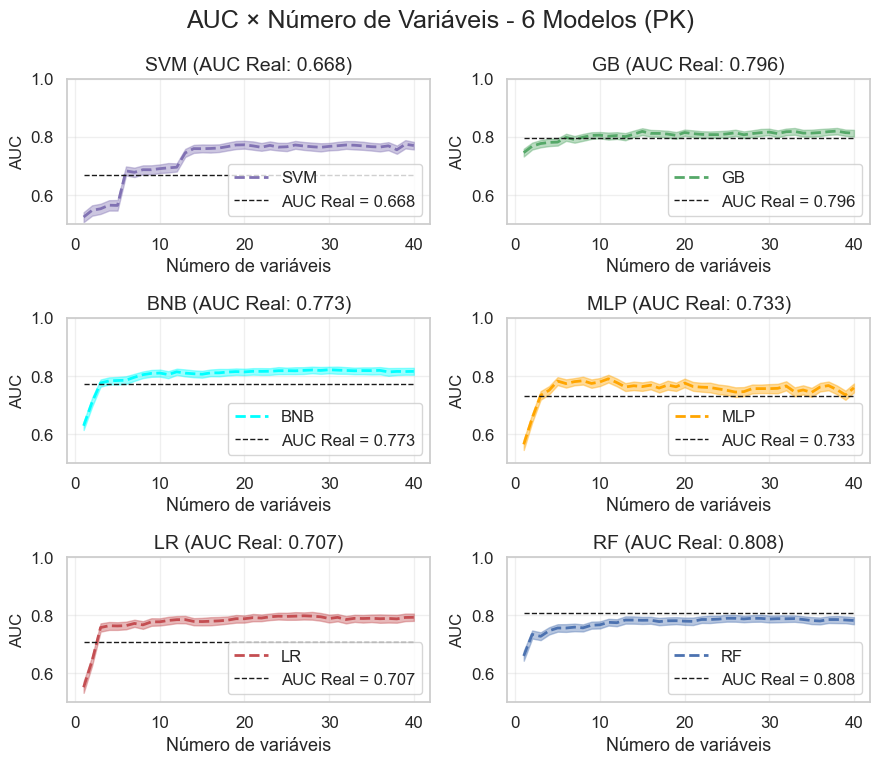

 Figura salva em: 5fold_PK/auc_vs_features_all_PK.png


In [ ]:


true_auc_PK = {}  

for model in ["lr", "svm", "rf", "gb", "bnb", "mlp"]:
    pkl_path = f"5fold_PK/{model}_results_PK.pkl"
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    auc_folds = data[0]         
    true_auc_PK[model] = float(np.mean(auc_folds))


sns.set(style="whitegrid", font_scale=1.1)

valid_models_PK = ['lr', 'svm', 'rf', 'gb', 'bnb', 'mlp']

files_PK = [
    f for f in os.listdir('5fold_PK')
    if f.endswith('_auc_low_hi_med_PK.npy') and f.split('_')[0] in valid_models_PK
]
print(f"Arquivos encontrados: {files_PK}")

auc_vals_PK, low_PK, high_PK, med_PK, name_PK = [], [], [], [], []

for f_PK in files_PK:
    a_PK, l_PK, m_PK, h_PK = np.load(os.path.join('5fold_PK', f_PK), allow_pickle=True)

    short = f_PK.split('_')[0]
    name_PK.append(short)


    a_PK, l_PK, m_PK, h_PK = [
        np.concatenate(([0.5], x)) for x in [a_PK, l_PK, m_PK, h_PK]
    ]

    auc_vals_PK.append(a_PK)
    low_PK.append(l_PK)
    high_PK.append(h_PK)
    med_PK.append(m_PK)

short2name_PK = {
    'lr': 'LR',
    'svm': 'SVM',
    'rf': 'RF',
    'gb': 'GB',
    'bnb': 'BNB',
    'mlp': 'MLP'
}

colors_PK = {
    'lr': 'r',
    'svm': 'm',
    'rf': 'b',
    'gb': 'g',
    'bnb': 'cyan',
    'mlp': 'orange'
}

def plot_auc_feat_PK(auc_PK, low_PK, med_PK, high_PK, name_PK, i_PK, col_PK, ax_PK):
    a_PK, l_PK, h_PK, m_PK = (
        auc_PK[i_PK][1:41],
        low_PK[i_PK][1:41],
        high_PK[i_PK][1:41],
        med_PK[i_PK][1:41],
    )

    x_PK = list(range(1, len(a_PK) + 1))

    modelo_short = name_PK[i_PK]
    modelo_label = short2name_PK[modelo_short]

    final_auc_PK = true_auc_PK[modelo_short]

    ax_PK.plot(x_PK, m_PK, '--', linewidth=2, color=col_PK, label=modelo_label)
    ax_PK.fill_between(x_PK, l_PK, h_PK, alpha=0.4, color=col_PK)

    ax_PK.plot(
        x_PK,
        np.ones(len(x_PK)) * final_auc_PK,
        'k--',
        label=f"AUC Real = {final_auc_PK:.3f}",
        linewidth=1
    )

    ax_PK.set_ylim(0.5, 1)
    ax_PK.set_xlabel('Número de variáveis', fontsize=13)
    ax_PK.set_ylabel('AUC', fontsize=12)
    ax_PK.legend(
    loc='lower right',
    fontsize=12,           
    title_fontsize=13,     
)
    ax_PK.grid(alpha=0.3)
    ax_PK.set_title(f"{modelo_label} (AUC Real: {final_auc_PK:.3f})", fontsize=14)


num_models_PK = len(files_PK)
cols = 2
rows = int(np.ceil(num_models_PK / cols))

fig_PK = plt.figure(figsize=(9, 2.6 * rows))
spec_PK = gridspec.GridSpec(ncols=cols, nrows=rows, figure=fig_PK)


for i_PK in range(len(files_PK)):
    ax_PK = fig_PK.add_subplot(spec_PK[i_PK])
    col_PK = colors_PK[name_PK[i_PK]]
    plot_auc_feat_PK(auc_vals_PK, low_PK, med_PK, high_PK, name_PK, i_PK, col_PK, ax_PK)

plt.suptitle('AUC × Número de Variáveis - 6 Modelos (PK)', fontsize=18)
plt.tight_layout()
plt.savefig('5fold_PK/auc_vs_features_all_PK.png', dpi=300)
plt.show()

print(" Figura salva em: 5fold_PK/auc_vs_features_all_PK.png")


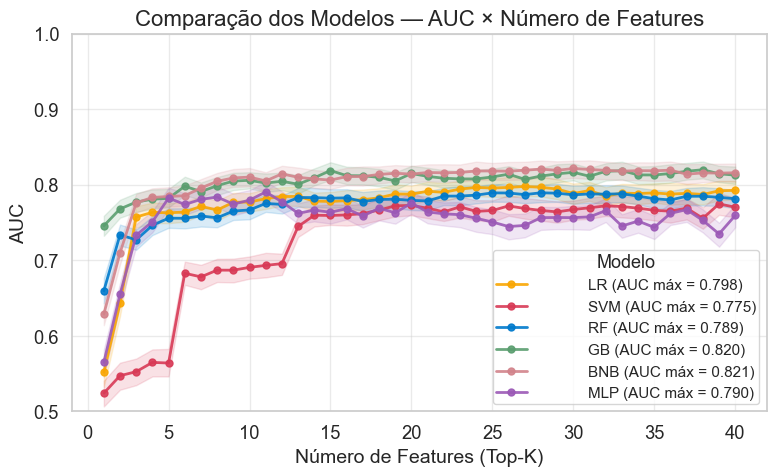


Figura salva em: 5fold_PK/auc_vs_features_comparison_PK.png


In [ ]:


sns.set(style="whitegrid", font_scale=1.2)

result_dir_PK = "5fold_PK"

models_PK = ['LR', 'SVM', 'RF', 'GB','BNB', 'MLP']

colors_PK = {
    'LR': '#F9A602',
    'SVM': '#D83A56',
    'RF': '#007ACC',
    'GB': '#5A9E6F',
    'BNB': "#D2838B",
    'MLP': '#9B59B6'
}

files_PK = {
    'LR': os.path.join(result_dir_PK, 'lr_auc_low_hi_med_PK.npy'),
    'SVM': os.path.join(result_dir_PK, 'svm_auc_low_hi_med_PK.npy'),
    'RF': os.path.join(result_dir_PK, 'rf_auc_low_hi_med_PK.npy'),
    'GB': os.path.join(result_dir_PK, 'gb_auc_low_hi_med_PK.npy'),
    'BNB': os.path.join(result_dir_PK, 'bnb_auc_low_hi_med_PK.npy'),
    'MLP': os.path.join(result_dir_PK, 'mlp_auc_low_hi_med_PK.npy')
}

plt.figure(figsize=(8, 5))

for model_PK in models_PK:
    auc_vals_PK, low_PK, med_PK, high_PK = np.load(files_PK[model_PK], allow_pickle=True)
    
    if len(med_PK) == 41:
        med_to_plot_PK = med_PK[1:]
        low_to_plot_PK = low_PK[1:]
        high_to_plot_PK = high_PK[1:]
    else:
        med_to_plot_PK = med_PK
        low_to_plot_PK = low_PK
        high_to_plot_PK = high_PK
    
    x_PK = np.arange(1, len(med_to_plot_PK) + 1)
    
    plt.plot(
        x_PK, med_to_plot_PK, '-o',
        linewidth=2,
        markersize=5,
        alpha=0.9,
        color=colors_PK[model_PK],
        label=f"{model_PK} (AUC máx = {np.max(med_to_plot_PK):.3f})"
    )

    plt.fill_between(
        x_PK, low_to_plot_PK, high_to_plot_PK,
        color=colors_PK[model_PK],
        alpha=0.15
    )

plt.xlabel('Número de Features (Top-K)', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Comparação dos Modelos — AUC × Número de Features', fontsize=16)
plt.ylim(0.5, 1.0)
plt.legend(
    title='Modelo',
    fontsize=11,
    title_fontsize=13,
    loc='lower right',
    frameon=True,
    borderpad=0.2,       
    handletextpad=4.0,   
)

plt.grid(alpha=0.4)
plt.tight_layout()

save_path_PK = os.path.join(result_dir_PK, "auc_vs_features_comparison_PK.png")
plt.savefig(save_path_PK, dpi=300)
plt.show()

print(f"\nFigura salva em: {save_path_PK}")

Top-20 variáveis mais recorrentes entre TODOS os modelos (PK):


,Variável,Frequência
0,NACCAGE,5
1,COGSTAT_0.0,4
2,COGSTAT_2.0,4
3,TRAILB,4
4,DECIN,4
5,MEMORY_0.0,3
6,NACCAMD,3
7,MMSEORDA_4.0,3
8,CDRGLOB_0.0,3
9,COGATTN,3


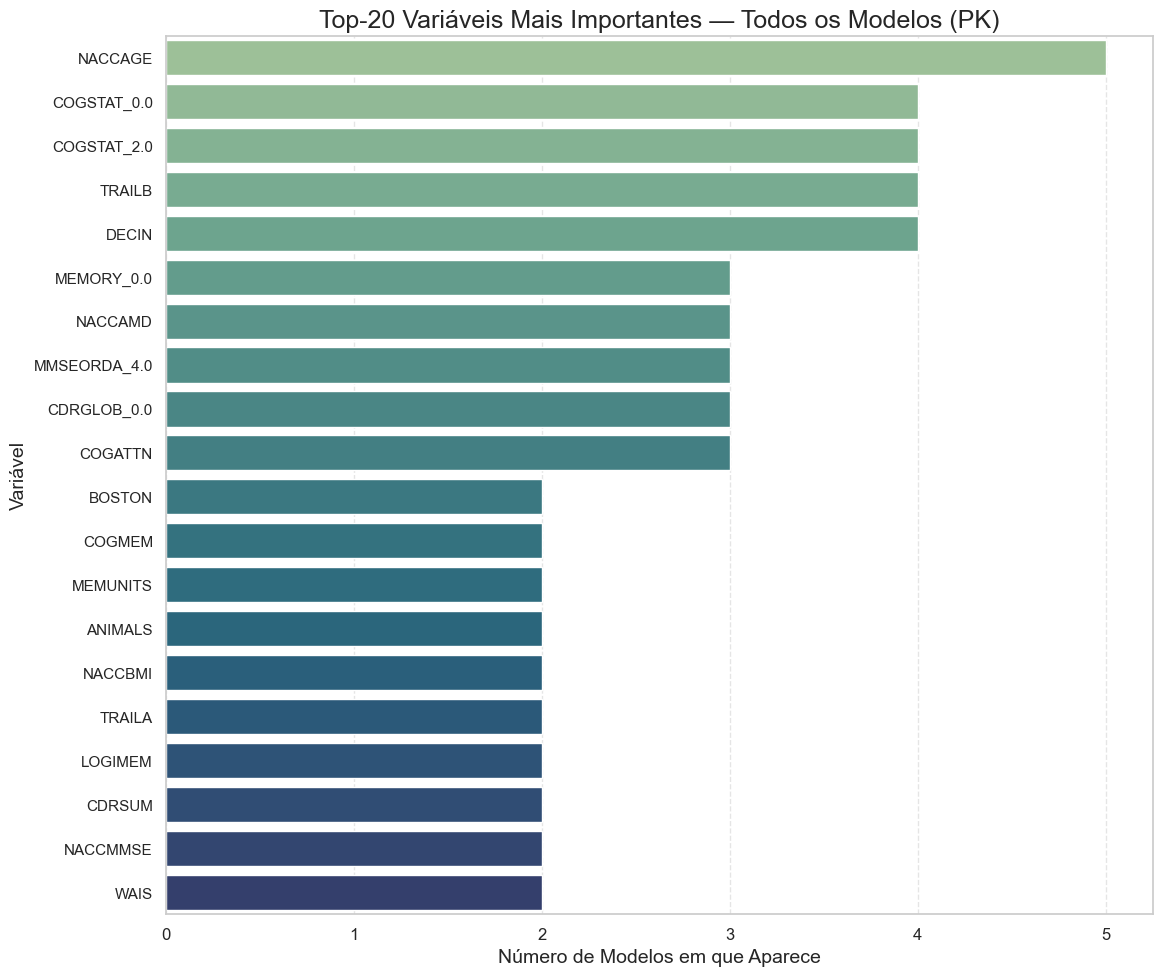


 Figura salva como: 5fold_PK/top20_features_PK.png


In [ ]:


def get_top_k_PK(feat_list_PK, final_variable_names_PK, k=20):
    arr = np.array(feat_list_PK)

    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    imp_mean = np.mean(np.abs(arr), axis=0)
    idx_sorted = np.argsort(-imp_mean)

    return [final_variable_names_PK[i] for i in idx_sorted[:k]]


model_names_PK = ["LR", "SVM", "RF", "GB",  "MLP"]

feat_dict_PK = {
    "LR":  lr_feat_PK,
    "SVM": svm_feat_PK,
    "RF":  rf_feat_PK,
    "GB":  gb_feat_PK,
    "MLP": mlp_feat_PK
}

top20_dict_PK = {}

for m in model_names_PK:
    feat_list_PK = feat_dict_PK[m]
    top20_dict_PK[m] = get_top_k_PK(feat_list_PK, final_variable_names_PK, k=20)



all_features_PK = sum(top20_dict_PK.values(), [])

freq_df_PK = (
    pd.Series(all_features_PK)
    .value_counts()
    .reset_index()
)
freq_df_PK.columns = ["Variável", "Frequência"]

freq_top20_PK = freq_df_PK.head(20)

print("Top-20 variáveis mais recorrentes entre TODOS os modelos (PK):")
display(freq_top20_PK)


plt.figure(figsize=(14, max(8, len(freq_top20_PK) * 0.5)))

sns.barplot(
    data=freq_top20_PK,
    x="Frequência",
    y="Variável",
    palette="crest"
)

plt.title("Top-20 Variáveis Mais Importantes — Todos os Modelos (PK)", fontsize=18)
plt.xlabel("Número de Modelos em que Aparece", fontsize=14)
plt.ylabel("Variável", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 1])  
plt.subplots_adjust(left=0.28)       

plt.savefig("5fold_PK/top20_features_PK.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Figura salva como: 5fold_PK/top20_features_PK.png")


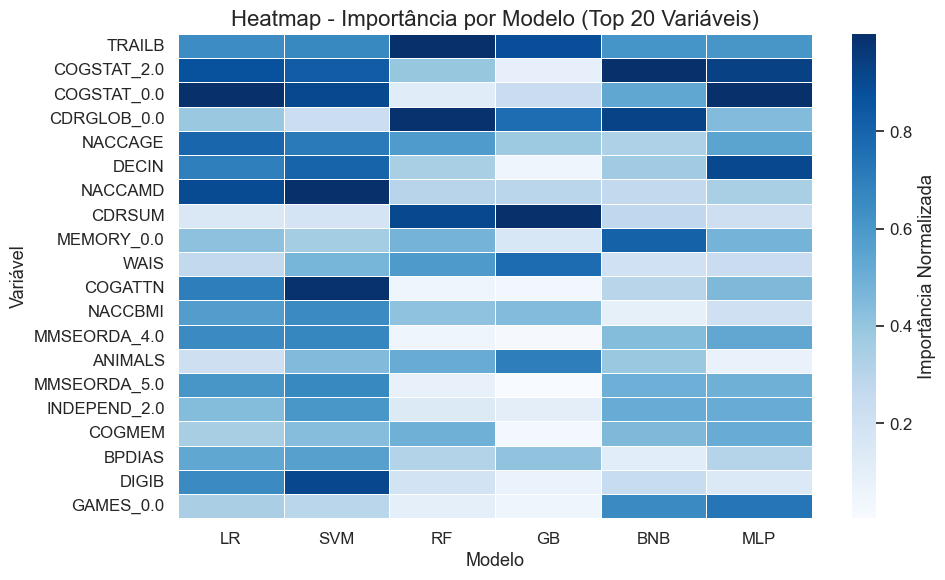

✓ Heatmap salvo em: 5fold_PK/heatmap_importancias_top20_PK.png


In [ ]:


sns.set(style="whitegrid", font_scale=1.1)


def load_feat_and_vars(model_name):
    with open(f"5fold_PK/{model_name}_results_PK.pkl", "rb") as f:
        auc, metrics, models, err, feat, probs, preds, variables = pickle.load(f)
    return feat, variables


feat_lr,  variables_PK = load_feat_and_vars("lr")
feat_svm, _ = load_feat_and_vars("svm")
feat_rf,  _ = load_feat_and_vars("rf")
feat_gb,  _ = load_feat_and_vars("gb")
feat_bnb, _ = load_feat_and_vars("bnb")
feat_mlp, _ = load_feat_and_vars("mlp")

model_names = ["LR", "SVM", "RF", "GB", "BNB", "MLP"]
feat_dict = {
    "LR":  feat_lr,
    "SVM": feat_svm,
    "RF":  feat_rf,
    "GB":  feat_gb,
    "BNB": feat_bnb,
    "MLP": feat_mlp,
}

all_vars = list(variables_PK)

imp_mat = pd.DataFrame(index=all_vars)

for m in model_names:
    feat_list = np.array(feat_dict[m])

    if feat_list.ndim == 1:
        feat_list = feat_list.reshape(1, -1)

    imp_mean = np.mean(np.abs(feat_list), axis=0)

    imp_norm = imp_mean / (imp_mean.max() + 1e-9)

    imp_mat[m] = imp_norm


top20_vars = imp_mat.mean(axis=1).sort_values(ascending=False).head(20).index
imp20 = imp_mat.loc[top20_vars]


plt.figure(figsize=(10, 6))
sns.heatmap(
    imp20,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={'label': 'Importância Normalizada'},
)

plt.title("Heatmap - Importância por Modelo (Top 20 Variáveis)", fontsize=16)
plt.xlabel("Modelo", fontsize=13)
plt.ylabel("Variável", fontsize=13)
plt.tight_layout()

plt.savefig("5fold_PK/heatmap_importancias_top20_PK.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Heatmap salvo em: 5fold_PK/heatmap_importancias_top20_PK.png")
